# <font color="#FF4500"><b> Mission 1. 패션 스타일 이미지 분류</b></font>


In [ ]:
# 런타임 재시작 (필요 시 실행)
!kill -9 -1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
training_image_dir = '/content/drive/MyDrive/data_creator_camp/training_image'
validation_image_dir = '/content/drive/MyDrive/data_creator_camp/validation_image'

training_label_dir = '/content/drive/MyDrive/data_creator_camp/training_label'
validation_label_dir = '/content/drive/MyDrive/data_creator_camp/validation_label'

* * *
### **Mask R-CNN 모델로 이미지 시맨틱 분할 처리할 때**

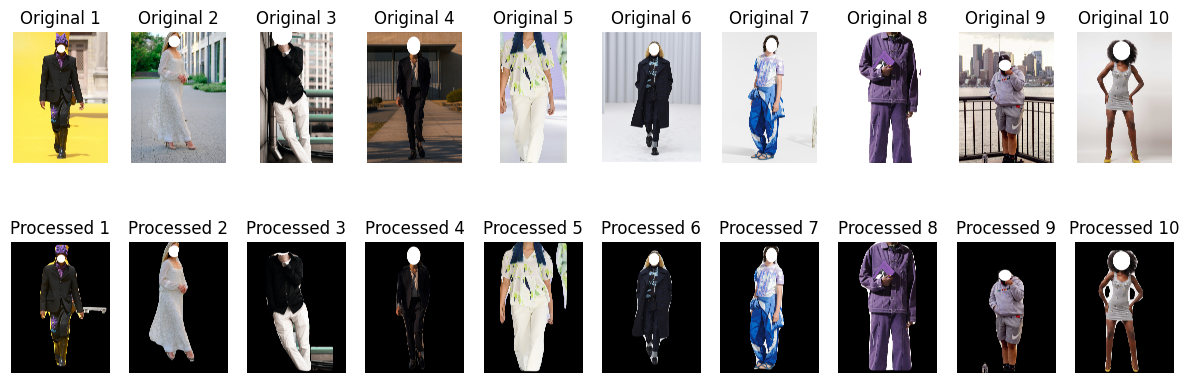

In [ ]:
# 결과 시각화
plt.figure(figsize=(15, 5))
for i, (orig, proc) in enumerate(zip(original_images, sample_processed_images)):
    plt.subplot(2, 10, i + 1)
    plt.imshow(orig)
    plt.axis('off')
    plt.title(f'Original {i + 1}')

    plt.subplot(2, 10, i + 11)
    plt.imshow(proc)
    plt.axis('off')
    plt.title(f'Processed {i + 1}')
plt.show()


### **데이터 불러오기**

In [ ]:
import os
import time

def get_chunks(directory):
    chunk = []
    retry_attempts = 3  # 최대 재시도 횟수
    attempt = 0

    while attempt < retry_attempts:
        try:
            with os.scandir(directory) as it:
                for entry in it:
                    if entry.is_file() and entry.name.endswith('.json'):
                        try:
                            # 파일이 정상적으로 처리되는 경우
                            chunk.append(entry.name)
                            print(f"{entry.name} 파일이 청크에 추가되었습니다.")
                        except Exception as file_error:
                            # 파일 처리 중 오류 발생 시 해당 파일명과 오류 출력
                            print(f"파일 처리 중 오류 발생: {entry.name}, 오류: {file_error}")
            return chunk
        except OSError as e:
            print(f"OSError 발생: {e}, {attempt + 1}번째 시도 중...")
            attempt += 1
            time.sleep(2)  # 2초 후 재시도
    raise OSError(f"{retry_attempts}회 시도 후에도 실패하였습니다.")

# 5000개씩 불러오는 과정
training_json_chunks = list(get_chunks(training_label_dir))
validation_json_chunks = list(get_chunks(validation_label_dir))

import itertools

training_image_files = [f for f in os.listdir(training_image_dir) if f.endswith('.jpg')]
validation_image_files = [f for f in os.listdir(validation_image_dir) if f.endswith('.jpg')]

# 모든 파일 이름을 하나의 리스트로 연결 (5000개씩 가져오기)
training_label_json_files = list(itertools.chain(*training_json_chunks))
validation_label_json_files = list(itertools.chain(*validation_json_chunks))

In [ ]:
import pickle
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/complete_image_label_files.pkl'

# pickle 파일로부터 리스트 로드
with open(pickle_file_path, 'rb') as f:
    data = pickle.load(f)

# 저장된 리스트 변수에 할당
training_image_files = data['training_image_files']
validation_image_files = data['validation_image_files']
training_label_json_files = data['training_label_json_files']
validation_label_json_files = data['validation_label_json_files']

print("리스트가 pickle 파일로부터 성공적으로 로드되었습니다.")

리스트가 pickle 파일로부터 성공적으로 로드되었습니다.


In [ ]:
print(len(training_image_files))
print(len(validation_image_files))

4070
951


In [ ]:
print(len(training_label_json_files))
print(len(validation_label_json_files))
print(len(training_image_files))
print(len(validation_image_files))

211346
36383
4070
951


### **데이터프레임 생성**

In [ ]:
import pandas as pd

def extract_info(filename):
  data = []
  for file in filename:
      if file.endswith('.json'):
          filename = file.replace('.json', '')
      elif file.endswith('.jpg'):
          filename = file.replace('.jpg', '')

      split_filename = filename.split('_')
      data.append(split_filename)
  return data

# 데이터프레임으로 변환
training_image_df = pd.DataFrame(extract_info(training_image_files), columns=['W/T', '이미지ID', '시대별', '스타일별', '성별'])
validation_image_df = pd.DataFrame(extract_info(validation_image_files), columns=['W/T', '이미지ID', '시대별', '스타일별', '성별'])
training_label_df = pd.DataFrame(extract_info(training_label_json_files), columns=['W/T', '이미지ID', '시대별', '스타일별', '성별', '설문ID'])
validation_label_df = pd.DataFrame(extract_info(validation_label_json_files), columns=['W/T', '이미지ID', '시대별', '스타일별', '성별', '설문ID'])


In [ ]:
import pandas as pd

def extract_info(filename):
  data = []
  for file in filename:
      if file.endswith('.jpg'):
          filename = file.replace('.jpg', '')

      split_filename = filename.split('_')
      data.append(split_filename)
  return data

# 데이터프레임으로 변환

training_image_df=pd.DataFrame(extract_info(training_image_files)
,columns=['W/T','이미지ID','시대별','스타일별','성별'])
validation_image_df=pd.DataFrame(extract_info(validation_image_files)
,columns=['W/T','이미지ID','시대별','스타일별','성별'])


training_label_df = pd.DataFrame(extract_info(training_label_json_files), columns=['W/T', '이미지ID', '시대별', '스타일별', '성별', '설문ID'])
validation_label_df = pd.DataFrame(extract_info(validation_label_json_files), columns=['W/T', '이미지ID', '시대별', '스타일별', '성별', '설문ID'])


In [ ]:
print(training_image_df.shape)
print(validation_image_df.shape)

(4070, 5)
(951, 5)


In [ ]:
import pickle
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/image_label_dataframes.pkl'

# pickle 파일로부터 리스트 저장
with open(pickle_file_path, 'wb') as f:
    pickle.dump({
        'training_image_df': training_image_df,
        'validation_image_df': validation_image_df,
        'training_label_df': training_label_df,
        'validation_label_df': validation_label_df
    }, f)

print("리스트가 pickle 파일로 저장되었습니다.")


리스트가 pickle 파일로 저장되었습니다.


In [ ]:
# 이미지 파일에서 성별 및 스타일을 추출하여 클래스 레이블 생성
def create_labels(image_files):
    labels = []
    for file in image_files:
        parts = file.split('_')
        style = parts[3]  # 스타일
        gender = parts[4][0]  # 성별
        class_label = f"{gender}_{style}"  # 성별과 스타일을 결합하여 클래스 라벨 생성
        labels.append(class_label)
    return labels

# 각 이미지 파일에 대해 클래스 라벨 생성
train_labels = create_labels(training_image_files)
val_labels = create_labels(validation_image_files)

# 고유한 클래스 레이블을 인덱스로 변환
unique_labels = sorted(set(train_labels + val_labels))
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}

# 각 이미지에 해당하는 클래스 인덱스 생성
train_class_indices = [label_to_idx[label] for label in train_labels]
val_class_indices = [label_to_idx[label] for label in val_labels]

# 데이터셋을 전처리 전 변수로 할당
train_data = training_image_files
val_data = validation_image_files


### **Mission 1-1 Training "성별&스타일" 통계치**

In [ ]:

train_result=training_image_df.groupby(['스타일별', '성별']).size().reset_index(name='이미지 수')


print(train_result)

              스타일별 성별  이미지 수
0       athleisure  W     67
1    bodyconscious  W     95
2             bold  M    268
3         cityglam  W     67
4          classic  W     77
5            disco  W     37
6          ecology  W     64
7         feminine  W    154
8       genderless  W     77
9           grunge  W     31
10          hiphop  M    274
11          hiphop  W     48
12          hippie  M    260
13          hippie  W     91
14             ivy  M    237
15          kitsch  W     91
16        lingerie  W     55
17          lounge  W     45
18     metrosexual  M    278
19        military  W     33
20         minimal  W    139
21            mods  M    269
22        normcore  M    364
23        normcore  W    153
24        oriental  W     78
25          popart  W     41
26       powersuit  W    120
27            punk  W     65
28           space  W     37
29  sportivecasual  M    298
30  sportivecasual  W    157


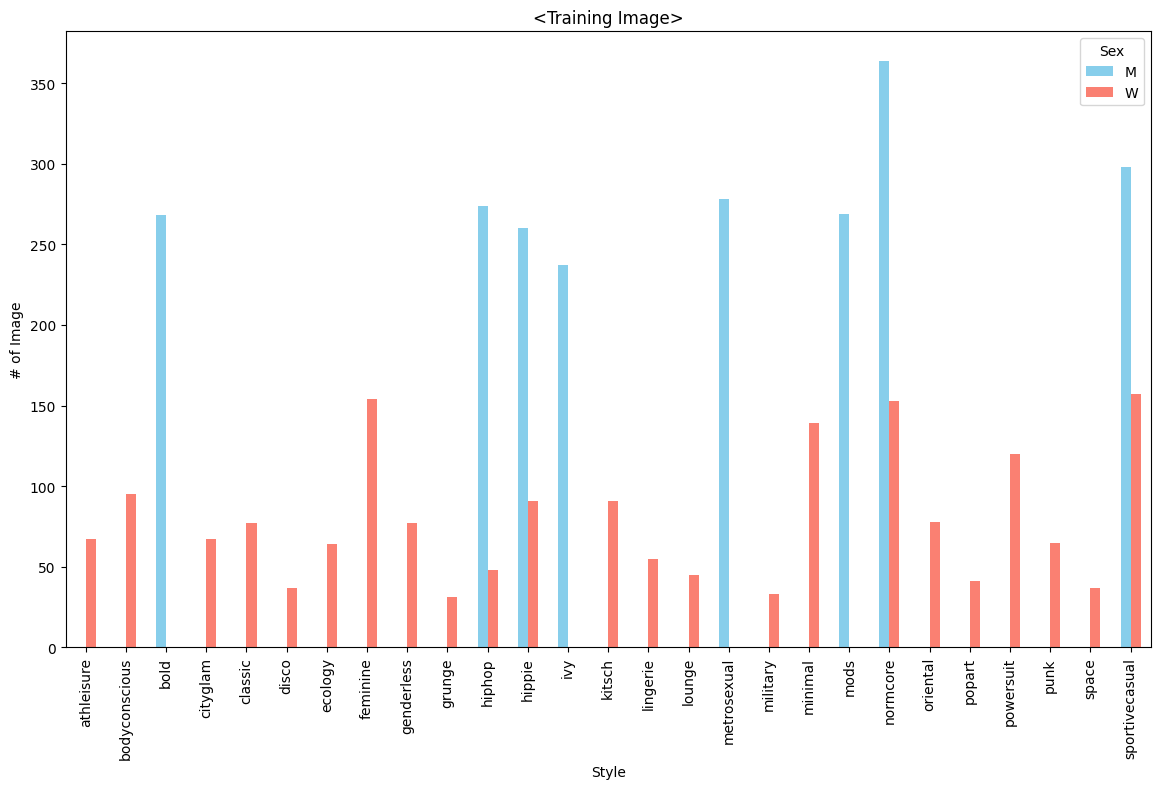

In [ ]:
# 성별별로 스타일과 이미지 수를 구분하여 피벗 테이블 생성
pivot_df = train_result.pivot(index='스타일별', columns='성별', values='이미지 수').fillna(0)

# 막대 그래프 그리기
pivot_df.plot(kind='bar', figsize=(14, 8), color=['skyblue', 'salmon'])
plt.xticks(rotation=90)
plt.xlabel('Style')
plt.ylabel('# of Image')
plt.title('<Training Image>')
plt.legend(title='Sex')
plt.show()

In [ ]:
val_result=validation_image_df.groupby(['스타일별', '성별']).size().reset_index(name='이미지 수')


val_result

,스타일별,성별,이미지 수
0,athleisure,W,14
1,bodyconscious,W,23
2,bold,M,57
3,cityglam,W,18
4,classic,W,22
5,disco,W,10
6,ecology,W,17
7,feminine,W,44
8,genderless,W,12
9,grunge,W,10


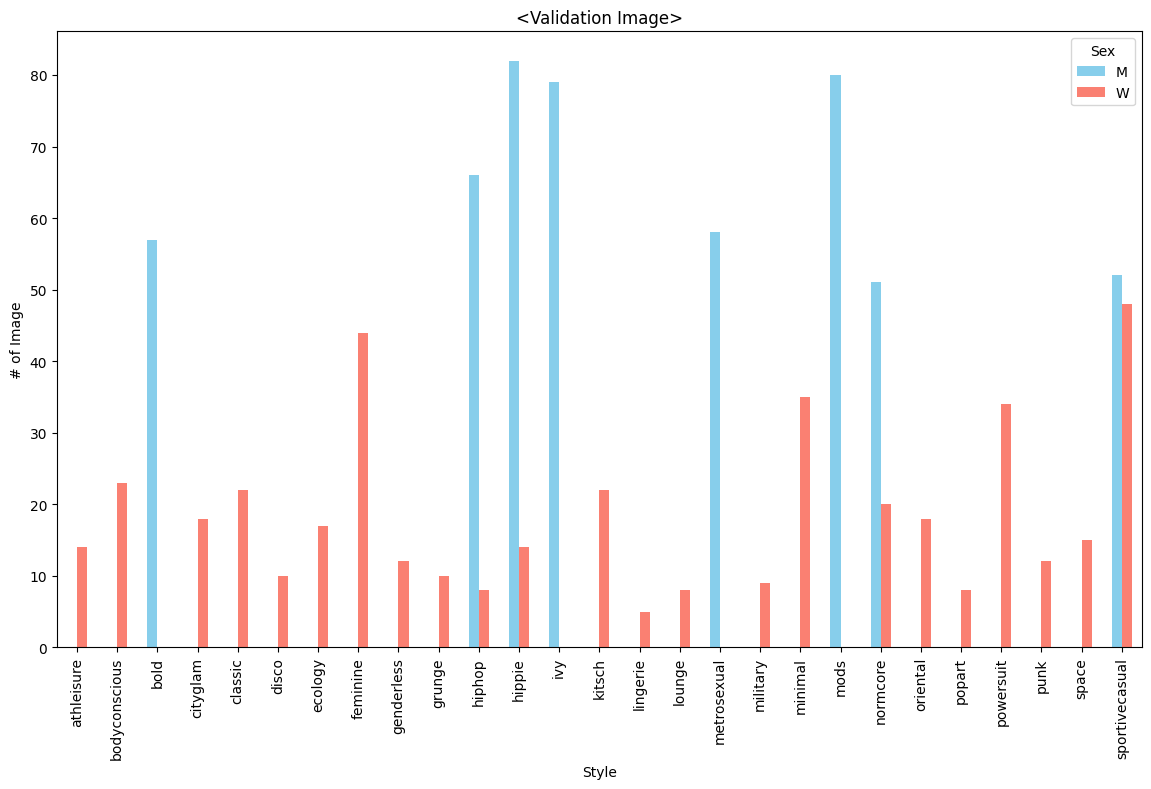

In [ ]:
# 성별별로 스타일과 이미지 수를 구분하여 피벗 테이블 생성
val_pivot_df = val_result.pivot(index='스타일별', columns='성별', values='이미지 수').fillna(0)

# 막대 그래프 그리기
val_pivot_df.plot(kind='bar', figsize=(14, 8), color=['skyblue', 'salmon'])
plt.xticks(rotation=90)
plt.xlabel('Style')
plt.ylabel('# of Image')
plt.title('<Validation Image>')
plt.legend(title='Sex')
plt.show()

### **Mission 1-1 Validation "성별&스타일" 통계치**

In [ ]:
# '스타일별'과 '성별'로 groupby를 하고 각 그룹의 크기를 count
mission1_validation_df=validation_image_df.groupby(['스타일별', '성별']).size().reset_index(name='이미지 수')

# 결과 출력
mission1_validation_df

,스타일별,성별,이미지 수
0,athleisure,W,14
1,bodyconscious,W,23
2,bold,M,57
3,cityglam,W,18
4,classic,W,22
5,disco,W,10
6,ecology,W,17
7,feminine,W,44
8,genderless,W,12
9,grunge,W,10


### **Mission 1-2. ResNet-18모델로 패션 이미지 분류하기**

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.8/362.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.2/233.2 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 7.8 MB/s eta 0:00:00


In [ ]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models import resnet18
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from PIL import Image
import numpy as np
import cv2
import os

In [ ]:
# Device 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# TensorBoard 설정
writer = SummaryWriter()

# Mask R-CNN 모델 로드
mask_rcnn = maskrcnn_resnet50_fpn(pretrained=True).to(device).eval()


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100%|██████████| 170M/170M [00:00<00:00, 219MB/s]


In [ ]:
# 데이터 증강 및 전처리
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5498, 0.5226, 0.5052], std=[0.2690, 0.2669, 0.2705])
])

Training Set Mean: tensor([0.5498, 0.5226, 0.5052])

Training Set Std: tensor([0.2690, 0.2669, 0.2705])

In [ ]:
# Dataset 클래스 정의
class FashionDataset(Dataset):
    def __init__(self, image_dir, fname, transform=None):
        self.image_paths = [os.path.join(training_image_dir, fname)
               for fname in training_image_files]
        self.transform = transform
        self.cache = {}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        if idx in self.cache:
            image = self.cache[idx]
        else:
            image = Image.open(self.image_paths[idx]).convert('RGB')
            image = self.remove_background(image)
            self.cache[idx] = image

        if self.transform:
            image = self.transform(image)

        label = self.get_label_from_path(self.image_paths[idx])
        return image, label

    def remove_background(self, image, threshold=0.5):
        input_image = transforms.ToTensor()(image).unsqueeze(0).to(device)
        with torch.no_grad():
            prediction = mask_rcnn(input_image)[0]

        # 높은 확률의 마스크들 결합
        combined_mask = np.zeros((image.height, image.width), dtype=np.uint8)
        for i in range(len(prediction['scores'])):
            if prediction['scores'][i] > threshold:
                mask = prediction['masks'][i, 0].cpu().numpy() > 0.5
                mask_resized = cv2.resize(mask.astype(np.uint8), (image.width, image.height), interpolation=cv2.INTER_NEAREST)
                combined_mask = np.maximum(combined_mask, mask_resized)

        # 마스크 적용
        masked_image = np.array(image) * combined_mask[:, :, None]
        return Image.fromarray(masked_image)


    def get_label_from_path(self, path):
        filename = os.path.basename(path)
        parts = filename.split('_')
        style = parts[3]
        gender = parts[4][0]
        class_label = f"{gender}_{style}"

        label_idx = label_to_idx[class_label]
        return label_idx


시간 오래 걸리니깐 데이터 1/10로 줄여서 일단 잘 돌아가는지 체크



```
from torch.utils.data import Subset
import numpy as np

# 데이터셋을 1/10로 줄이기 위해 인덱스 샘플링
train_indices = np.random.choice(len(training_image_files), len(training_image_files) // 10, replace=False)
valid_indices = np.random.choice(len(validation_image_files), len(validation_image_files) // 10, replace=False)

# Subset을 사용하여 축소된 데이터셋 생성
train_subset = Subset(FashionDataset(training_image_dir, training_image_files, transform=transform), train_indices)
valid_subset = Subset(FashionDataset(validation_image_dir, validation_image_files, transform=transform), valid_indices)

# DataLoader 설정
train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=4)
valid_dataloader = DataLoader(valid_subset, batch_size=32, shuffle=True, num_workers=4)

```



In [ ]:
# Dataset 및 DataLoader 설정
train_dataset = FashionDataset(training_image_dir, training_image_files, transform=transform)
valid_dataset = FashionDataset(validation_image_dir, validation_image_files, transform=transform)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, multiprocessing_context='spawn')
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=True, num_workers=2, multiprocessing_context='spawn')


In [ ]:
from collections import Counter
import torch

# 데이터셋의 클래스 분포 계산
class_counts = Counter(label for _, label in train_dataset)
class_counts = torch.tensor([class_counts[i] for i in range(31)], dtype=torch.float32)

# 클래스 가중치 계산 (클래스 개수에 반비례하여 설정)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()  # 정규화
class_weights = class_weights.to(device)  # GPU 사용 시 전송


KeyboardInterrupt: 

In [ ]:
import torch.nn.functional as F
from torch.optim import Adam, AdamW, Adamax, SGD
import torch.optim.lr_scheduler as lr_scheduler
import torch.nn.init as init
import optuna

# 모델 생성 함수
class CustomResNet(nn.Module):
    def __init__(self, trial, num_classes=31):
        super(CustomResNet, self).__init__()
        # ResNet-18 기본 구조 정의
        self.model = resnet18(weights=None)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

        # 활성화 함수 선택 (기본 LeakyReLU)
        activation_fn = trial.suggest_categorical("activation_fn", ["relu", "leaky_relu", "prelu", "elu", "selu"])
        if activation_fn == "leaky_relu":
            self.activation = nn.LeakyReLU()
        elif activation_fn == "prelu":
            self.activation = nn.PReLU()
        elif activation_fn == "elu":
            self.activation = nn.ELU()
        elif activation_fn == "selu":
            self.activation = nn.SELU()
        else:
            self.activation = nn.ReLU()

        # 가중치 초기화
        init_fn = trial.suggest_categorical("init_fn", ["xavier_uniform", "he_normal"])
        self.initialize_weights(init_fn)

    def forward(self, x):
        x = self.model(x)
        return self.activation(x)

    def initialize_weights(self, init_fn):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                if init_fn == "he_normal":
                    init.kaiming_normal_(m.weight)
                elif init_fn == "xavier_uniform":
                    init.xavier_uniform_(m.weight)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision.models import resnet18
from torch.utils.tensorboard import SummaryWriter
import optuna

# 하이퍼파라미터 튜닝 objective 함수
def objective(trial):
    # 모델 및 활성화 함수 선택
    model = CustomResNet(trial, num_classes=31).to(device)

    # 옵티마이저 선택
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "adamw", "adamax", "sgd"])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    elif optimizer_name == "adamax":
        optimizer = optim.Adamax(model.parameters(), lr=learning_rate)
    else:
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

    # 스케줄러 선택
    num_epochs = trial.suggest_int("epochs", 10, 100)
    scheduler = lr_scheduler.OneCycleLR(optimizer, max_lr=learning_rate, steps_per_epoch=len(train_dataloader), epochs=num_epochs)

    # 규제 추가
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    l1_lambda = trial.suggest_float("l1_lambda", 1e-5, 1e-2, log=True)
    l2_lambda = trial.suggest_float("l2_lambda", 1e-5, 1e-2, log=True)

    # 손실 함수 정의 (L1+L2 규제 적용)
    criterion = nn.CrossEntropyLoss() #weight=class_weights

    # 혼합 정밀도 학습 설정
    scaler = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None

    # 기울기 누적 설정
    accumulation_steps = 4  # 예: 누적할 스텝 수 설정

    # Early stopping 설정
    patience = 3
    best_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for i, (images, labels) in enumerate(train_dataloader):  # 수정된 부분
            images, labels = images.to(device), labels.to(device)

            # 기울기 초기화는 누적 단위로
            if i % accumulation_steps == 0:
                optimizer.zero_grad()

            # 혼합 정밀도 학습을 위한 AMP
            with torch.cuda.amp.autocast():
                outputs = model(images)

            # 규제를 포함한 손실 계산
            loss = criterion(outputs, labels)
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2.0).sum() for p in model.parameters())
            loss += l1_lambda * l1_norm + l2_lambda * l2_norm
            loss = loss / accumulation_steps  # 누적 스텝당 손실 조정

            # 기울기 누적한 후에만 최적화 수행
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()  # 누적이 끝나면 다시 기울기 초기화

            else:
                loss.backward()
                if (i + 1) % accumulation_steps == 0:
                    optimizer.step()
                    optimizer.zero_grad()

            running_loss += loss.item() * accumulation_steps  # 스케일 복구
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        # 스케줄러 업데이트
        scheduler.step()

        # Training loss 및 accuracy 계산
        train_loss = running_loss / len(train_dataloader)
        train_accuracy = 100 * correct / total

        # Validation Phase
        model.eval()
        valid_loss, valid_correct, valid_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in valid_dataloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valid_loss += loss.item()
                _, predicted = outputs.max(1)
                valid_total += labels.size(0)
                valid_correct += predicted.eq(labels).sum().item()

        # Validation loss 및 accuracy 계산
        valid_loss /= len(valid_dataloader)
        valid_accuracy = 100 * valid_correct / valid_total

        # TensorBoard 기록
        writer.add_scalar('Loss/train', train_loss, epoch)
        writer.add_scalar('Loss/valid', valid_loss, epoch)
        writer.add_scalar('Accuracy/train', train_accuracy, epoch)
        writer.add_scalar('Accuracy/valid', valid_accuracy, epoch)

        # Early stopping 체크
        if valid_loss < best_loss:
            best_loss = valid_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping")
                break

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Valid Acc: {valid_accuracy:.2f}%")

    # Early stopping 또는 최종 에폭 후, validation accuracy 반환
    return valid_accuracy


In [ ]:
# Optuna로 Bayesian Optimization 수행 (validation accuracy 기준으로 최대화)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

[I 2024-10-27 07:31:38,435] A new study created in memory with name: no-name-67faf5e6-36fa-4b0c-8d25-c2ca050f34f8
[W 2024-10-27 07:49:20,258] Trial 0 failed with parameters: {'activation_fn': 'leaky_relu', 'init_fn': 'he_normal', 'optimizer': 'adamax', 'learning_rate': 0.008845664249933891, 'epochs': 72, 'dropout_rate': 0.4755906741782255, 'l1_lambda': 1.4503706471285548e-05, 'l2_lambda': 1.2705581175070106e-05} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "<ipython-input-17-0c2092db8e0f>", line 55, in objective
    for i, (images, labels) in enumerate(train_dataloader):  # 수정된 부분
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 484, in __iter__
    return self._get_iterator()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 415, in

KeyboardInterrupt: 

In [ ]:
# 최적의 하이퍼파라미터 출력
print("Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value}")
print("  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

In [ ]:
# TensorBoard 시각화
writer.close()

In [ ]:
# Matplotlib로 시각화
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
plt.show()

# <font color="#FF4500"><b> Mission 2. 패션 스타일 선호 여부 예측</b></font>

### **mission 1-1에서 저장한 이미지& 라벨 경로, 파일 이름 리스트, 초기 데이터프레임 로드하기**

In [ ]:
training_image_dir = '/content/drive/MyDrive/data_creator_camp/training_image'
validation_image_dir = '/content/drive/MyDrive/data_creator_camp/validation_image'

training_label_dir = '/content/drive/MyDrive/data_creator_camp/training_label'
validation_label_dir = '/content/drive/MyDrive/data_creator_camp/validation_label'

In [ ]:
import pickle

def load_labels_pickle(pickle_file_path):
    # pickle 파일로부터 데이터를 로드
    with open(pickle_file_path, 'rb') as f:
        data = pickle.load(f)

    # 로드한 데이터에서 각 리스트를 반환
    existing_training_labels = data['existing_training_labels']
    missing_training_labels = data['missing_training_labels']
    existing_validation_labels = data['existing_validation_labels']
    missing_validation_labels = data['missing_validation_labels']

    print("리스트가 pickle 파일로부터 성공적으로 로드되었습니다.")
    return existing_training_labels, missing_training_labels, existing_validation_labels, missing_validation_labels

# 사용 예시
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/241104_missing_labels.pkl'
existing_training_labels, missing_training_labels, existing_validation_labels, missing_validation_labels = load_labels_pickle(pickle_file_path)


리스트가 pickle 파일로부터 성공적으로 로드되었습니다.


In [ ]:
print(len(existing_training_labels))
print(len(existing_validation_labels))
print(len(missing_training_labels))
print(len(missing_validation_labels))

211310
36380
36
3


In [ ]:
import pickle
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/complete_image_label_files.pkl'

# pickle 파일로부터 리스트 로드
with open(pickle_file_path, 'rb') as f:
    data = pickle.load(f)

# 저장된 리스트 변수에 할당
training_image_files = data['training_image_files']
validation_image_files = data['validation_image_files']
training_label_json_files = data['training_label_json_files']
validation_label_json_files = data['validation_label_json_files']

print("리스트가 pickle 파일로부터 성공적으로 로드되었습니다.")

리스트가 pickle 파일로부터 성공적으로 로드되었습니다.


In [ ]:
import pickle
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/image_label_dataframes.pkl'

# pickle 파일로부터 데이터 로드
with open(pickle_file_path, 'rb') as f:
    data = pickle.load(f)

# 저장된 데이터프레임 변수에 할당
training_image_df = data['training_image_df']
validation_image_df = data['validation_image_df']

print("데이터프레임이 pickle 파일로부터 성공적으로 로드되었습니다.")

데이터프레임이 pickle 파일로부터 성공적으로 로드되었습니다.


In [ ]:
import pickle
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/241027_Rid_json_files.pkl'

# pickle 파일로부터 데이터 로드
with open(pickle_file_path, 'rb') as f:
    data = pickle.load(f)

# 저장된 데이터프레임 변수에 할당
train_json_df = data['train_json_df']
valid_json_df = data['valid_json_df']

print("데이터프레임이 pickle 파일로부터 성공적으로 로드되었습니다.")

데이터프레임이 pickle 파일로부터 성공적으로 로드되었습니다.


In [ ]:
training_label_df = pd.DataFrame(extract_info(existing_training_labels),
                                 columns=['W/T', '이미지ID', '시대별', '스타일별', '성별', '설문ID'])
validation_label_df = pd.DataFrame(extract_info(existing_validation_labels),
                                   columns=['W/T', '이미지ID', '시대별', '스타일별', '성별', '설문ID'])

print(training_label_df.shape)
print(validation_label_df.shape)

(211310, 6)
(36380, 6)


In [ ]:
training_label_df

,W/T,이미지ID,시대별,스타일별,성별,설문ID
0,W,62795,10,sportivecasual,W,119352
1,W,49899,19,normcore,W,144005
2,T,09540,19,lounge,W,066132
3,T,02307,19,normcore,W,221322
4,T,01707,19,lounge,W,221167
...,...,...,...,...,...,...
211305,W,71576,60,mods,M,202012
211306,W,80483,60,mods,M,068200
211307,W,06532,60,mods,M,034290
211308,W,25462,60,mods,M,167492


In [ ]:
validation_label_df

,W/T,이미지ID,시대별,스타일별,성별,설문ID
0,W,51002,50,ivy,M,077511
1,W,50973,50,ivy,M,229191
2,W,50937,50,ivy,M,175247
3,W,50877,50,ivy,M,119243
4,W,50852,50,ivy,M,199493
...,...,...,...,...,...,...
36375,W,02722,60,mods,M,206810
36376,W,02845,60,mods,M,126636
36377,W,02816,60,mods,M,142957
36378,W,02816,60,mods,M,144666


* 원본 training label 데이터프레임에서, 각 응답자는 하나의 이미지에 대하여 설문평가를 진행한 것을 알 수 있다.
* 따라서 2-2의 "스타일 선호 정보표"를 구할 때 각 셀에 들어가는 이미지 파일 이름이 단독으로 들어갈 수 있다. 리스트가 아니라

### **Training image와 Training label에 일치하는 "이미지ID"를 식별하여 유효한 라벨링 데이터 추출**

* 방법 1: pd.merge를 이용하기

In [ ]:
# '이미지ID'를 기준으로 두 데이터프레임 병합 -> 공통된 이미지ID만 유지


train_df_v22 = pd.merge(training_label_df, training_image_df, on='이미지ID')
val_df_v22 = pd.merge(validation_label_df, validation_image_df, on='이미지ID')

print(train_df_v22.shape)
print(val_df_v22.shape)

(20323, 10)
(4262, 10)


In [ ]:
remained_columns = ['W/T_x', '이미지ID', '시대별_x', '스타일별_x', '성별_x', '설문ID']

train_df_v33 = train_df_v22[remained_columns]
val_df_v33 = val_df_v22[remained_columns]

train_df_v33.columns = train_df_v33.columns.str.replace('_x', '')
val_df_v33.columns = val_df_v33.columns.str.replace('_x', '')

print(train_df_v33.shape)
print(val_df_v33.shape)

(20323, 6)
(4262, 6)


In [ ]:
# 필요한 열만 리스트로 지정
# 지정한 열들만 선택하여 새로운 데이터프레임 생성
# 열 이름에서 '_x'를 제거

* <font color="red"><b>방법 2: isin을 이용하기</b></font>


In [ ]:
image_ids_in_train_img = training_image_df['이미지ID'].tolist()
image_ids_in_valid_img = validation_image_df['이미지ID'].tolist()

train_df_v2 = training_label_df[training_label_df['이미지ID'].isin(image_ids_in_train_img)]
val_df_v2 = validation_label_df[validation_label_df['이미지ID'].isin(image_ids_in_valid_img)]

print(train_df_v2.shape)
print(val_df_v2.shape)

(20301, 6)
(4262, 6)


In [ ]:
train_df_v2

,W/T,이미지ID,시대별,스타일별,성별,설문ID
58,T,06546,19,genderless,W,189146
67,T,10443,19,normcore,W,107933
74,T,05289,19,lounge,W,090915
107,T,12155,19,genderless,W,205586
122,W,41537,10,sportivecasual,W,008819
...,...,...,...,...,...,...
211275,W,12793,50,ivy,M,149512
211277,W,17530,50,ivy,M,150110
211278,W,24889,50,ivy,M,119272
211280,W,30040,60,mods,M,149504


In [ ]:
train_df_v3=train_df_v2.groupby(['성별','스타일별']).size().reset_index(name='라벨수')

train_df_v3

,성별,스타일별,라벨수
0,M,bold,1144
1,M,hiphop,1321
2,M,hippie,1571
3,M,ivy,1719
4,M,metrosexual,1226
5,M,mods,1615
6,M,normcore,1096
7,M,sportivecasual,1657
8,W,athleisure,424
9,W,bodyconscious,500


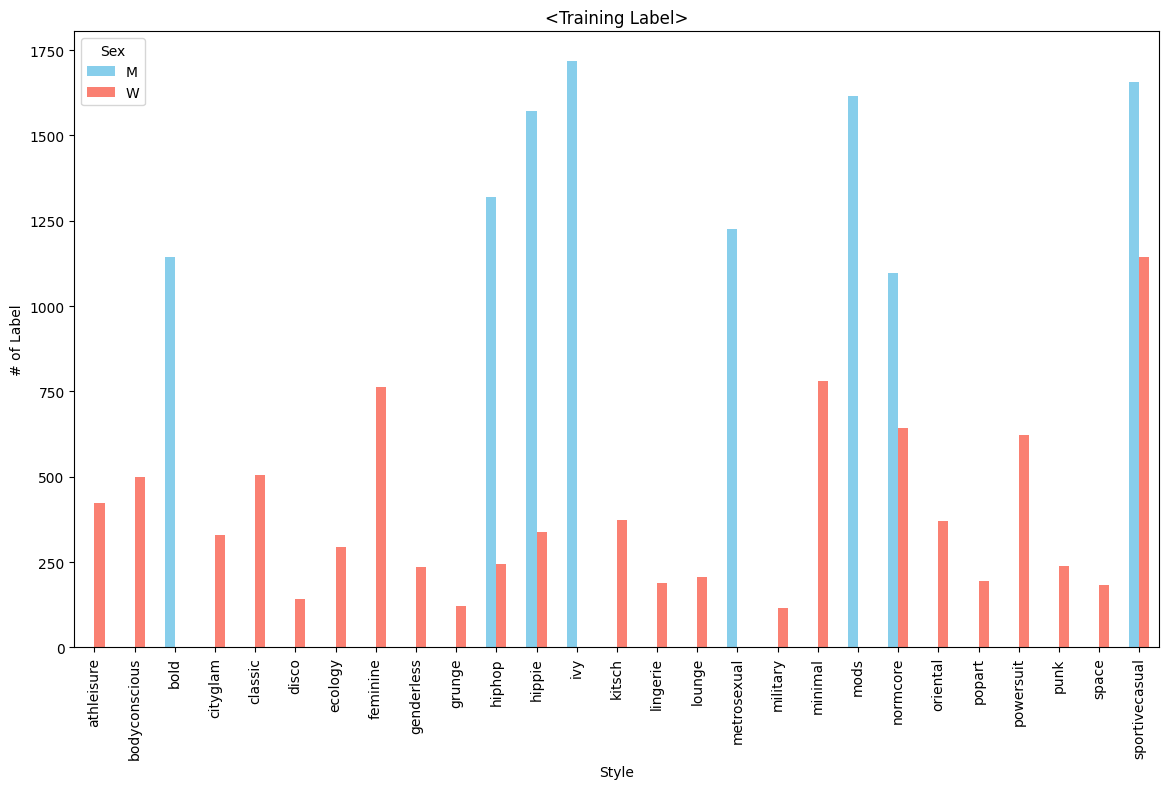

In [ ]:
# 성별별로 스타일과 이미지 수를 구분하여 피벗 테이블 생성
train_pivot2_df = train_df_v3.pivot(index='스타일별', columns='성별', values='라벨수').fillna(0)

# 막대 그래프 그리기
train_pivot2_df.plot(kind='bar', figsize=(14, 8), color=['skyblue', 'salmon'])
plt.xticks(rotation=90)
plt.xlabel('Style')
plt.ylabel('# of Label')
plt.title('<Training Label>')
plt.legend(title='Sex')
plt.show()

In [ ]:
val_df_v3=val_df_v2.groupby(['성별','스타일별']).size().reset_index(name='라벨수')

val_df_v3

,성별,스타일별,라벨수
0,M,bold,221
1,M,hiphop,259
2,M,hippie,474
3,M,ivy,537
4,M,metrosexual,224
5,M,mods,438
6,M,normcore,102
7,M,sportivecasual,180
8,W,athleisure,80
9,W,bodyconscious,114


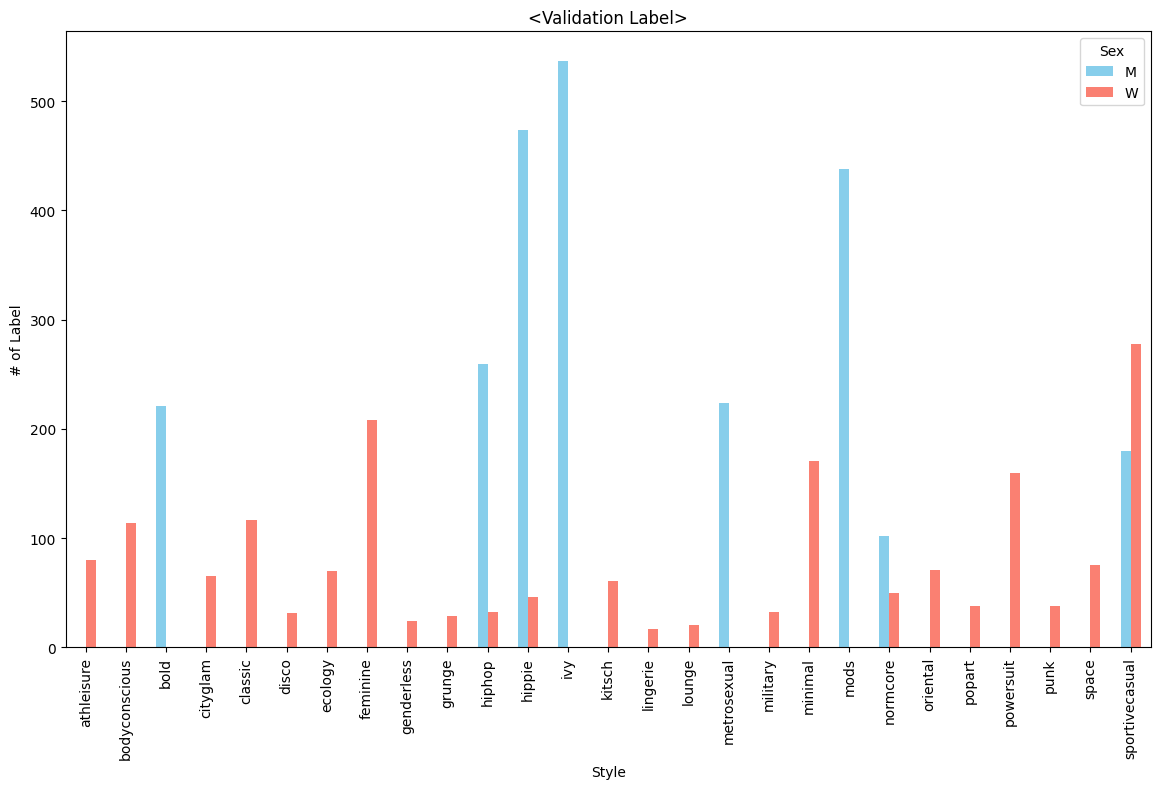

In [ ]:
# 성별별로 스타일과 이미지 수를 구분하여 피벗 테이블 생성
val_pivot2_df = val_df_v3.pivot(index='스타일별', columns='성별', values='라벨수').fillna(0)

# 막대 그래프 그리기
val_pivot2_df.plot(kind='bar', figsize=(14, 8), color=['skyblue', 'salmon'])
plt.xticks(rotation=90)
plt.xlabel('Style')
plt.ylabel('# of Label')
plt.title('<Validation Label>')
plt.legend(title='Sex')
plt.show()

In [ ]:
# training_image_df과 validation_image_df의 Image_ID 리스트 추출
# training_label_df과 validation_label_df에서 각각 training_image_df과 validation_image_df에 존재하는 Image_ID만 필터링

In [ ]:
final2_training_filtered_df

,W/T,이미지ID,시대별,스타일별,성별,설문ID
58,T,06546,19,genderless,W,189146
67,T,10443,19,normcore,W,107933
74,T,05289,19,lounge,W,090915
107,T,12155,19,genderless,W,205586
122,W,41537,10,sportivecasual,W,008819
...,...,...,...,...,...,...
211275,W,12793,50,ivy,M,149512
211277,W,17530,50,ivy,M,150110
211278,W,24889,50,ivy,M,119272
211280,W,30040,60,mods,M,149504


### **<GPT답변>**

`isin`의 결과값이 `pd.merge`보다 작게 나오는 이유는 여러 가지 요인에서 발생할 수 있습니다. 그 차이는 두 방식이 데이터를 처리하는 방식에 대한 미묘한 차이에서 발생하는데요, 아래에서 몇 가지 가능성을 설명하겠습니다.

##### 1. **`isin`과 `merge`의 매칭 방식 차이**
   - **`isin`**은 단순히 리스트에 포함된 값들을 기반으로 필터링합니다. 만약 `training_label_df`에서 `Image_ID` 컬럼의 값 중 일부가 `training_image_df`에 존재하지 않거나, `Image_ID`가 NaN 값인 경우에도 이를 무시하지 않고 포함될 수 있습니다.
   - **`pd.merge`**는 `inner join`을 기본적으로 수행하기 때문에, 양쪽에 있는 모든 값들이 완전히 일치해야만 해당 행이 결과에 포함됩니다. 즉, `Image_ID`가 양쪽에 모두 존재하는 경우에만 남깁니다.

##### 2. **중복 여부**
   
   - <font color="red"><b>`pd.merge`는 일치하는 값이 양쪽 데이터프레임에 여러 번 나타날 수 있습니다. 만약 `training_label_df`에 동일한 `Image_ID`가 여러 번 있으면, `training_image_df`에서 동일한 `Image_ID`와 매칭된 여러 행이 조인되어 결과에서 더 많은 행이 생성될 수 있습니다.</b></font>
  
   - 반대로, `isin`은 조건에 맞는 행만 필터링하고 중복 행을 따로 생성하지 않기 때문에 결과적으로 더 적은 행이 남을 수 있습니다.

##### 3. **결측값 (NaN) 처리**
   - `isin`을 사용할 때 `NaN` 값은 필터링 대상에서 제외되지 않고 처리될 수 있지만, `merge`는 `NaN`을 매칭하지 않기 때문에 결과에 포함되지 않습니다. 따라서 `merge`의 결과가 더 많을 수 있습니다.

##### 4. **양쪽 데이터프레임에 없는 값**
   - `pd.merge`는 양쪽에 모두 존재하는 값만 조인하지만, `isin`은 필터링 기준이 되는 리스트에 없는 값들은 필터링에서 제외됩니다. 이 과정에서 `isin`이 양쪽 데이터프레임의 값 중 일부를 제거할 수 있습니다.

##### 결론:
- **`isin`이 더 작은 이유**는 `training_label_df`의 `Image_ID`가 `training_image_df`에 있는 `Image_ID`와 일치하지 않는 부분이 있을 가능성이 크며, `isin`으로는 이를 필터링하면서 일부 행이 제거된 것입니다.
- **`pd.merge`가 더 큰 이유**는 동일한 `Image_ID`가 양쪽에 여러 번 등장하여 중복된 매칭이 일어나면서 결과적으로 행이 더 많아지는 것입니다.

이런 차이를 확인하려면, `training_image_df`와 `training_label_df`에서 `Image_ID`가 중복되는지, 결측값이 있는지 등을 확인해 보면 좋습니다.

### **Mission 2-1. Training에 대한 "이미지ID"수 기준으로 "성별& 스타일" 통계치**

In [ ]:
# 병합된 데이터프레임에서 '스타일별'과 '성별'로 그룹화하여 이미지 수 계산
mission2_training_df = final2_training_filtered_df.groupby(['스타일별', '성별']).size().reset_index(name='이미지 수')

# 결과 출력
mission2_training_df

,스타일별,성별,이미지 수
0,athleisure,W,424
1,bodyconscious,W,500
2,bold,M,1144
3,cityglam,W,329
4,classic,W,504
5,disco,W,141
6,ecology,W,295
7,feminine,W,762
8,genderless,W,234
9,grunge,W,122


### **Mission 2-1. Validation에 대한 "이미지ID"수 기준으로 "성별& 스타일" 통계치**

In [ ]:
# 병합된 데이터프레임에서 '스타일별'과 '성별'로 그룹화하여 이미지 수 계산
mission2_validation_df = final2_validation_filtered_df.groupby(['스타일별', '성별']).size().reset_index(name='이미지 수')

# 결과 출력
mission2_validation_df

,스타일별,성별,이미지 수
0,athleisure,W,80
1,bodyconscious,W,114
2,bold,M,221
3,cityglam,W,65
4,classic,W,117
5,disco,W,31
6,ecology,W,70
7,feminine,W,208
8,genderless,W,24
9,grunge,W,29


### **유효한 이미지ID를 가진 json파일 읽어 데이터프레임으로 저장**

In [ ]:
final2_training_filtered_df.groupby(['이미지ID']).size().describe()

,0
count,4066.000000
mean,4.993606
std,1.910535
min,1.000000
25%,4.000000
50%,5.000000
75%,6.000000
max,12.000000


In [ ]:
final2_validation_filtered_df.groupby(['이미지ID']).size().describe()

,0
count,951.000000
mean,4.482650
std,1.607045
min,1.000000
25%,3.000000
50%,4.000000
75%,6.000000
max,11.000000


* training label과 validation label에서 각각 최대 12, 11개의 '이미지ID'가 중복되므로 unique함수의 필요성이 대두된다.

* 지금은 unique적용하나 안하나 결과값이 똑같지만 나중에 혹시 모르니까 일단 unique함수 적용된거 만들어 놓기

In [ ]:
image_ids_in_train_final = final2_training_filtered_df['이미지ID'].tolist()
image_ids_in_valid_final = final2_validation_filtered_df['이미지ID'].tolist()
unique_image_ids_in_train_final = final2_training_filtered_df['이미지ID'].unique().tolist()
unique_image_ids_in_valid_final = final2_validation_filtered_df['이미지ID'].unique().tolist()

# '이미지ID'로부터 JSON 파일 이름을 생성 (예: '{이미지ID}.json')
# 파일 이름에서 이미지ID를 추출하고, 이를 리스트로 필터링하는 코드
train_json_files = [file for file in training_label_json_files if file.split('_')[1] in image_ids_in_train_final]
valid_json_files = [file for file in validation_label_json_files if file.split('_')[1] in image_ids_in_valid_final]


KeyboardInterrupt: 

In [ ]:
len(image_ids_in_train_final), len(image_ids_in_valid_final) (4066, 951)

(20304, 4263)

In [ ]:
len(train_json_files), len(valid_json_files)

(20304, 4263)

필터링된 파일 이름을 사용하여 JSON 파일을 읽어오는 함수 호출

In [ ]:
import json
import os
import pandas as pd

def read_json_files(json_file_list, base_directory):
    records = []
    total_files = len(json_file_list)

    for idx, file_name in enumerate(json_file_list):
        file_path = os.path.join(base_directory, file_name)

        with open(file_path, 'r') as f:
            data = json.load(f)

        survey_id = data['user'].get('R_id')
        img_name = data.get('imgName')
        q5_value = data['item']['survey'].get('Q5')

        records.append({'설문ID': survey_id, '이미지 이름': img_name, '스타일 선호여부': q5_value})

    json_df = pd.DataFrame(records)
    return json_df

In [ ]:
import json
import os
import pandas as pd

def read_json_files(json_file_list, base_directory):
    records = []
    total_files = len(json_file_list)

    # 각 JSON 파일에 대해 반복
    for idx, file_name in enumerate(json_file_list):
        file_path = os.path.join(base_directory, file_name)

        try:
            with open(file_path, 'r') as f:
                data = json.load(f)

            # JSON 데이터에서 필요한 값 추출
            survey_id = data['user'].get('R_id')
            img_name = data.get('imgName')
            q5_value = data['item']['survey'].get('Q5')

            records.append({'설문ID': survey_id, '이미지 이름': img_name, '스타일 선호여부': q5_value})

        except OSError as e:
            print(f"Error reading {file_name}: {e}")
            continue

        # 진행 상황 출력
        if (idx + 1) % 100 == 0:  # 100개의 파일을 처리할 때마다 출력
            print(f"{idx + 1}/{total_files} files processed")

    # 최종적으로 리스트를 DataFrame으로 변환
    json_df = pd.DataFrame(records)

    return json_df


In [ ]:
valid_json_df = read_json_files(valid_json_files, validation_label_dir)

Error reading W_51514_50_ivy_M_061638.json: [Errno 5] Input/output error: '/content/drive/MyDrive/data_creator_camp/validation_label/W_51514_50_ivy_M_061638.json'
100/4263 files processed
200/4263 files processed
300/4263 files processed
400/4263 files processed
500/4263 files processed
600/4263 files processed
700/4263 files processed
800/4263 files processed
900/4263 files processed
1000/4263 files processed
1100/4263 files processed
1200/4263 files processed
1300/4263 files processed
1400/4263 files processed
1500/4263 files processed
1600/4263 files processed
1700/4263 files processed
1800/4263 files processed
1900/4263 files processed
2000/4263 files processed
2100/4263 files processed
2200/4263 files processed
2300/4263 files processed
2400/4263 files processed
2500/4263 files processed
2600/4263 files processed
2700/4263 files processed
2800/4263 files processed
2900/4263 files processed
3000/4263 files processed
3100/4263 files processed
3200/4263 files processed
3300/4263 file

In [ ]:
valid_json_df # 4262 rows × 3 columns

,설문ID,이미지 이름,스타일 선호여부
0,65139,W_51514_50_ivy_M.jpg,1
1,64930,W_51514_50_ivy_M.jpg,1
2,65114,W_51514_50_ivy_M.jpg,2
3,65491,W_51514_50_ivy_M.jpg,1
4,65430,W_51577_50_ivy_M.jpg,2
...,...,...,...
4256,63026,W_02736_60_mods_M.jpg,2
4257,63505,W_02845_60_mods_M.jpg,2
4258,64148,W_02816_60_mods_M.jpg,2
4259,64216,W_02816_60_mods_M.jpg,2


In [ ]:
train_json_df = read_json_files(train_json_files, training_label_dir)

Error reading W_08232_19_normcore_W_118560.json: [Errno 5] Input/output error: '/content/drive/MyDrive/data_creator_camp/training_label/W_08232_19_normcore_W_118560.json'
Error reading T_02024_19_normcore_W_221339.json: [Errno 5] Input/output error: '/content/drive/MyDrive/data_creator_camp/training_label/T_02024_19_normcore_W_221339.json'
Error reading T_06546_19_genderless_W_189146.json: [Errno 5] Input/output error: '/content/drive/MyDrive/data_creator_camp/training_label/T_06546_19_genderless_W_189146.json'
Error reading T_10443_19_normcore_W_107933.json: [Errno 5] Input/output error: '/content/drive/MyDrive/data_creator_camp/training_label/T_10443_19_normcore_W_107933.json'
Error reading T_05289_19_lounge_W_090915.json: [Errno 5] Input/output error: '/content/drive/MyDrive/data_creator_camp/training_label/T_05289_19_lounge_W_090915.json'
Error reading T_12155_19_genderless_W_205586.json: [Errno 5] Input/output error: '/content/drive/MyDrive/data_creator_camp/training_label/T_12155

In [ ]:
train_json_df # 20303 rows × 3 columns

NameError: name 'train_json_df' is not defined

In [ ]:
import pickle

# 파일 경로 설정
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/241027_Rid_json_files.pkl'

# 4개의 리스트를 pickle로 저장
with open(pickle_file_path, 'wb') as f:
    pickle.dump({
        'train_json_files': train_json_files,
        'valid_json_files': valid_json_files,
        'train_json_df': train_json_df,
        'valid_json_df': valid_json_df
    }, f)

print("리스트가 pickle 파일로 저장되었습니다.")

리스트가 pickle 파일로 저장되었습니다.


In [ ]:
import pickle

# 파일 경로 설정
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/241027_Rid_json_files.pkl'

# pickle 파일로부터 데이터 로드
with open(pickle_file_path, 'rb') as f:
    data = pickle.load(f)

# 로드된 데이터에서 각 리스트를 개별 변수에 할당
train_json_files = data['train_json_files']
valid_json_files = data['valid_json_files']
train_json_df = data['train_json_df']
valid_json_df = data['valid_json_df']

print("리스트가 pickle 파일로부터 성공적으로 로드되었습니다.")


리스트가 pickle 파일로부터 성공적으로 로드되었습니다.


In [ ]:
training_label_df

,W/T,이미지ID,시대별,스타일별,성별,설문ID
0,W,62795,10,sportivecasual,W,119352
1,W,49899,19,normcore,W,144005
2,T,09540,19,lounge,W,066132
3,T,02307,19,normcore,W,221322
4,T,01707,19,lounge,W,221167
...,...,...,...,...,...,...
211305,W,71576,60,mods,M,202012
211306,W,80483,60,mods,M,068200
211307,W,06532,60,mods,M,034290
211308,W,25462,60,mods,M,167492


In [ ]:
# training_image_files 리스트에 있는 파일 이름만 남기는 코드
# 결과 출력

In [ ]:
train_json_df = train_json_df[train_json_df['이미지 이름'].isin(training_image_files)]
valid_json_df = valid_json_df[valid_json_df['이미지 이름'].isin(validation_image_files)]

print(train_json_df.shape)
print(valid_json_df.shape)

(16093, 3)
(4103, 3)


In [ ]:
train_json_df.groupby('설문ID').size().describe()

,0
count,3382.000000
mean,4.758427
std,7.568237
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,49.000000


In [ ]:
valid_json_df.groupby('설문ID').size().describe()

,0
count,1880.000000
mean,2.182447
std,2.360354
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,17.000000


Train 데이터프레임의 고유한 응답자 수: 4009

Validation 데이터프레임의 고유한 응답자 수: 1988

Train과 Validation에서 겹치는 고유한 응답자 수: 1922

In [ ]:
#train_df와 valid_df 각각 고유한 응답자 수 출력
print(f"Train 데이터프레임의 고유한 응답자 수: {train_json_df['설문ID'].nunique()}")
print(f"Validation 데이터프레임의 고유한 응답자 수: {valid_json_df['설문ID'].nunique()}")

# train_df와 valid_df에서 고유한 응답자 ID 추출
train_respondents = set(train_json_df['설문ID'].unique())
valid_respondents = set(valid_json_df['설문ID'].unique())

# 겹치는 응답자 ID 추출
common_respondents = train_respondents.intersection(valid_respondents)

# 겹치는 응답자 수 출력
num_common_respondents = len(common_respondents)

print(f"Train과 Validation에서 겹치는 고유한 응답자 수: {num_common_respondents}")

In [ ]:


train_respondents = set(train_json_df['설문ID'].unique())
valid_respondents = set(valid_json_df['설문ID'].unique())
common_respondents = train_respondents.intersection(valid_respondents)
num_common_respondents = len(common_respondents)

print(f"Train 데이터프레임의 고유한 응답자 수: {train_json_df['설문ID'].nunique()}")
print(f"Validation 데이터프레임의 고유한 응답자 수: {valid_json_df['설문ID'].nunique()}")
print(f"Train과 Validation에서 겹치는 고유한 응답자 수: {num_common_respondents}")

Train 데이터프레임의 고유한 응답자 수: 3382
Validation 데이터프레임의 고유한 응답자 수: 1880
Train과 Validation에서 겹치는 고유한 응답자 수: 1783


In [ ]:

train_respondents = set(train_json_df['설문ID'].unique())
valid_respondents = set(valid_json_df['설문ID'].unique())
common_respondents = train_respondents.intersection(valid_respondents)

filtered_train_df = train_json_df[train_json_df['설문ID'].isin(common_respondents)]
filtered_valid_df = valid_json_df[valid_json_df['설문ID'].isin(common_respondents)]

train_image_names = set(filtered_train_df['이미지 이름'])
filtered_valid_df_not_in_train = filtered_valid_df[~filtered_valid_df['이미지 이름'].isin(train_image_names)]

print(filtered_valid_df_not_in_train)


In [ ]:

train_respondents = set(train_json_df['설문ID'].unique())
valid_respondents = set(valid_json_df['설문ID'].unique())
common_respondents = train_respondents.intersection(valid_respondents)

# common_respondents에 포함된 설문ID만 필터링
filtered_train_df = train_json_df[train_json_df['설문ID'].isin(common_respondents)]
filtered_valid_df = valid_json_df[valid_json_df['설문ID'].isin(common_respondents)]

# filtered_train_df의 '이미지 이름' 컬럼 값을 집합(set)으로 변환
train_image_names = set(filtered_train_df['이미지 이름'])

# filtered_valid_df에서 '이미지 이름'이 train_image_names에 없는 경우만 필터링
filtered_valid_df_not_in_train = filtered_valid_df[~filtered_valid_df['이미지 이름'].isin(train_image_names)]

# 결과 출력
print("filtered_valid_df에서 '이미지 이름'이 filtered_train_df에 없는 데이터프레임:")
print(filtered_valid_df_not_in_train)


filtered_valid_df에서 '이미지 이름'이 filtered_train_df에 없는 데이터프레임:
       설문ID                 이미지 이름  스타일 선호여부
17    67669   W_52521_50_ivy_M.jpg         1
18    67308   W_52521_50_ivy_M.jpg         1
19    67975   W_52578_50_ivy_M.jpg         2
20    67975   W_52521_50_ivy_M.jpg         1
21    51077   W_52521_50_ivy_M.jpg         1
...     ...                    ...       ...
4241  67117  W_02691_60_mods_M.jpg         1
4242  63505  W_02691_60_mods_M.jpg         2
4243  63934  W_02701_60_mods_M.jpg         2
4244  59783  W_02691_60_mods_M.jpg         2
4246  23471  W_02691_60_mods_M.jpg         1

[1557 rows x 3 columns]


In [ ]:
filtered_valid_df

,설문ID,이미지 이름,스타일 선호여부
0,65139,W_51514_50_ivy_M.jpg,1
1,64930,W_51514_50_ivy_M.jpg,1
2,65114,W_51514_50_ivy_M.jpg,2
3,65491,W_51514_50_ivy_M.jpg,1
4,65430,W_51577_50_ivy_M.jpg,2
...,...,...,...
4256,63026,W_02736_60_mods_M.jpg,2
4257,63505,W_02845_60_mods_M.jpg,2
4258,64148,W_02816_60_mods_M.jpg,2
4259,64216,W_02816_60_mods_M.jpg,2


In [ ]:
filtered_valid_df.groupby('설문ID').size().describe()

,0
count,1783.000000
mean,2.243410
std,2.408174
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,17.000000


In [ ]:
filtered_train_df

,설문ID,이미지 이름,스타일 선호여부
0,66731,W_67492_19_lounge_W.jpg,2
1,66592,T_06320_19_normcore_W.jpg,2
5,63108,W_11391_19_genderless_W.jpg,2
7,42469,W_03476_19_lounge_W.jpg,2
11,66592,T_09717_19_genderless_W.jpg,2
...,...,...,...
20290,28468,W_10082_50_ivy_M.jpg,1
20291,64447,W_12793_50_ivy_M.jpg,2
20292,64471,W_17530_50_ivy_M.jpg,2
20294,64441,W_30040_60_mods_M.jpg,2


In [ ]:
filtered_train_df.groupby('설문ID').size().describe()

,0
count,1783.000000
mean,7.107123
std,9.712435
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
max,49.000000


In [ ]:
filtered_valid_df_not_in_train.groupby('설문ID').size().describe()

,0
count,930.000000
mean,1.674194
std,1.320649
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,11.000000


In [ ]:
train_top_respondents = (
    filtered_train_df.groupby('설문ID').size()
    .sort_values(ascending=False)
    .head(100)
    .index
)
valid_top_respondents = (
    filtered_valid_df_not_in_train.groupby('설문ID').size()
    .sort_values(ascending=False)
    .head(100)
    .index
)

train_json_df_v2 = filtered_train_df[filtered_train_df['설문ID'].isin(train_top_respondents)]
valid_json_df_v2 = filtered_valid_df_not_in_train[filtered_valid_df_not_in_train['설문ID'].isin(train_top_respondents)]

# 결과 출력
print("상위 100명의 설문ID를 포함하는 train_json_df_v2:")
print(train_json_df_v2)
print(valid_json_df_v2)


In [ ]:
# 설문ID별로 그룹화하여 응답자 수를 계산하고, 내림차순으로 정렬 후 상위 100명 추출
train_top_respondents = (
    filtered_train_df.groupby('설문ID').size()
    .sort_values(ascending=False)
    .head(100)
    .index
)
valid_top_respondents = (
    filtered_valid_df_not_in_train.groupby('설문ID').size()
    .sort_values(ascending=False)
    .head(100)
    .index
)

# 상위 100명의 설문ID에 해당하는 데이터만 필터링하여 새로운 DataFrame 생성
train_json_df_v2 = filtered_train_df[filtered_train_df['설문ID'].isin(train_top_respondents)]

# valid_json_df_v2를 train의 상위 100명과 동일한 설문ID로 필터링
valid_json_df_v2 = filtered_valid_df_not_in_train[filtered_valid_df_not_in_train['설문ID'].isin(train_top_respondents)]

# 결과 출력
print("상위 100명의 설문ID를 포함하는 train_json_df_v2:")
print(train_json_df_v2)
print(valid_json_df_v2)


상위 100명의 설문ID를 포함하는 train_json_df_v2:
        설문ID                       이미지 이름  스타일 선호여부
0      66731      W_67492_19_lounge_W.jpg         2
1      66592    T_06320_19_normcore_W.jpg         2
11     66592  T_09717_19_genderless_W.jpg         2
18     63601  W_18441_19_genderless_W.jpg         1
22     63359  W_00410_19_genderless_W.jpg         2
...      ...                          ...       ...
20265  63508         W_15294_50_ivy_M.jpg         2
20271  63571        W_16082_60_mods_M.jpg         2
20274  64441        W_25235_60_mods_M.jpg         1
20289  63927         W_15080_50_ivy_M.jpg         1
20294  64441        W_30040_60_mods_M.jpg         2

[4453 rows x 3 columns]
       설문ID                 이미지 이름  스타일 선호여부
19    67975   W_52578_50_ivy_M.jpg         2
20    67975   W_52521_50_ivy_M.jpg         1
28    61859   W_00012_50_ivy_M.jpg         2
42    28912   W_00012_50_ivy_M.jpg         1
54    63769   W_04207_50_ivy_M.jpg         1
...     ...                    ...       ..

In [ ]:
print(train_json_df_v2.shape)
train_json_df_v2.groupby('설문ID').size().describe()

(4453, 3)


,0
count,100.000000
mean,44.530000
std,2.042256
min,38.000000
25%,43.000000
50%,45.000000
75%,46.000000
max,49.000000


In [ ]:
print(valid_json_df_v2.shape)
valid_json_df_v2.groupby('설문ID').size().describe()

(455, 3)


,0
count,100.000000
mean,4.550000
std,1.961112
min,1.000000
25%,3.000000
50%,4.000000
75%,6.000000
max,11.000000


### **응답자 전체 "스타일 선호 정보표"**

### **Mission 2-2. "스타일 선호 정보표"**

In [ ]:
import pandas as pd

def restructure_df(df):
    grouped = df.groupby('설문ID')
    records = []

    for survey_id, group in grouped:
        preferred_images = group.loc[group['스타일 선호여부'] == 2, '이미지 이름'].tolist()
        non_preferred_images = group.loc[group['스타일 선호여부'] == 1, '이미지 이름'].tolist()

        records.append({
            '설문ID': survey_id,
            '스타일 선호': preferred_images,
            '스타일 비선호': non_preferred_images
        })

    new_df = pd.DataFrame(records)
    return new_df

train_restructured_df = restructure_df(train_json_df_v2)
valid_restructured_df = restructure_df(valid_json_df_v2)

# 결과 확인
print(train_restructured_df)  # 각 설문ID별 선호 및 비선호 이미지 리스트가 포함된 DataFrame
print(valid_restructured_df)

In [ ]:
import pandas as pd

def restructure_df(df):
    # 설문ID별로 데이터를 그룹화
    grouped = df.groupby('설문ID')

    # 새로운 데이터 구조를 담을 리스트
    records = []

    # 각 설문ID 그룹에 대해 처리
    for survey_id, group in grouped:
        # 스타일 선호(2) 및 비선호(1)를 각각 필터링하여 이미지 이름 리스트로 선택
        preferred_images = group.loc[group['스타일 선호여부'] == 2, '이미지 이름'].tolist()
        non_preferred_images = group.loc[group['스타일 선호여부'] == 1, '이미지 이름'].tolist()

        # 하나의 레코드 생성 (설문ID, 스타일 선호, 스타일 비선호)
        records.append({
            '설문ID': survey_id,
            '스타일 선호': preferred_images,
            '스타일 비선호': non_preferred_images
        })

    # 리스트를 DataFrame으로 변환
    new_df = pd.DataFrame(records)
    return new_df

# 예시: train_json_df와 valid_json_df에 대해 적용
train_restructured_df = restructure_df(train_json_df_v2)
valid_restructured_df = restructure_df(valid_json_df_v2)

# 결과 확인
print(train_restructured_df)  # 각 설문ID별 선호 및 비선호 이미지 리스트가 포함된 DataFrame
print(valid_restructured_df)


     설문ID                                             스타일 선호  \
0     368  [W_06896_10_sportivecasual_M.jpg, W_16403_10_s...   
1     837  [W_28211_19_normcore_M.jpg, W_17010_10_sportiv...   
2    7658  [W_11170_19_normcore_W.jpg, W_06322_19_lounge_...   
3    7905  [W_16293_80_bold_M.jpg, W_24765_60_mods_M.jpg,...   
4    9096  [W_11329_19_normcore_W.jpg, W_02085_19_lounge_...   
..    ...                                                ...   
95  66469  [T_02558_19_normcore_M.jpg, T_02527_10_sportiv...   
96  66513  [T_07416_19_lounge_W.jpg, W_50265_19_normcore_...   
97  66592  [T_06320_19_normcore_W.jpg, T_09717_19_genderl...   
98  66731  [W_67492_19_lounge_W.jpg, T_14085_19_genderles...   
99  67975  [W_60191_10_sportivecasual_M.jpg, T_17799_19_n...   

                                              스타일 비선호  
0   [W_00905_19_normcore_M.jpg, W_06263_19_normcor...  
1   [W_11107_19_normcore_M.jpg, W_32173_19_normcor...  
2   [W_13266_19_normcore_W.jpg, W_11169_19_normcor...  
3   [W_

In [ ]:
train_restructured_df

,설문ID,스타일 선호,스타일 비선호
0,368,"[W_06896_10_sportivecasual_M.jpg, W_16403_10_s...","[W_00905_19_normcore_M.jpg, W_06263_19_normcor..."
1,837,"[W_28211_19_normcore_M.jpg, W_17010_10_sportiv...","[W_11107_19_normcore_M.jpg, W_32173_19_normcor..."
2,7658,"[W_11170_19_normcore_W.jpg, W_06322_19_lounge_...","[W_13266_19_normcore_W.jpg, W_11169_19_normcor..."
3,7905,"[W_16293_80_bold_M.jpg, W_24765_60_mods_M.jpg,...","[W_27319_10_sportivecasual_M.jpg, W_29873_19_n..."
4,9096,"[W_11329_19_normcore_W.jpg, W_02085_19_lounge_...","[W_08232_19_normcore_W.jpg, W_03461_19_normcor..."
...,...,...,...
95,66469,"[T_02558_19_normcore_M.jpg, T_02527_10_sportiv...","[W_52198_19_normcore_M.jpg, W_53078_19_normcor..."
96,66513,"[T_07416_19_lounge_W.jpg, W_50265_19_normcore_...","[W_56334_10_sportivecasual_W.jpg, W_34173_19_n..."
97,66592,"[T_06320_19_normcore_W.jpg, T_09717_19_genderl...","[W_64036_10_athleisure_W.jpg, W_55797_00_ecolo..."
98,66731,"[W_67492_19_lounge_W.jpg, T_14085_19_genderles...","[T_14071_19_lounge_W.jpg, W_40003_10_sportivec..."


In [ ]:
valid_restructured_df

,설문ID,스타일 선호,스타일 비선호
0,368,"[W_00551_19_normcore_M.jpg, W_06864_10_sportiv...","[W_16848_19_normcore_M.jpg, W_16034_80_bold_M...."
1,837,"[W_06590_90_hiphop_M.jpg, W_10104_60_mods_M.jpg]","[W_31439_19_normcore_M.jpg, W_12154_80_bold_M...."
2,7658,"[W_09731_19_genderless_W.jpg, W_04927_50_femin...","[W_14923_60_minimal_W.jpg, W_19003_50_feminine..."
3,7905,[W_32034_80_bold_M.jpg],"[W_15319_50_ivy_M.jpg, W_28964_19_normcore_M.j..."
4,9096,"[W_19205_00_oriental_W.jpg, W_18714_90_kitsch_...","[W_06011_80_powersuit_W.jpg, W_14225_50_femini..."
...,...,...,...
95,66469,"[T_01514_50_ivy_M.jpg, W_52417_00_metrosexual_...","[W_58887_00_metrosexual_M.jpg, W_24553_70_hipp..."
96,66513,[],"[W_44520_70_punk_W.jpg, W_14914_50_feminine_W...."
97,66592,[],"[W_35400_80_powersuit_W.jpg, W_22056_70_hippie..."
98,66731,[],[W_22783_70_hippie_W.jpg]


In [ ]:
import pickle

# 파일 경로 설정
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/241105_mission2results_v2.pkl'

# 4개의 리스트를 pickle로 저장
with open(pickle_file_path, 'wb') as f:
    pickle.dump({
        'train_json_df_v2': train_json_df_v2,
        'valid_json_df_v2': valid_json_df_v2,
        'train_restructured_df': train_restructured_df,
        'valid_restructured_df': valid_restructured_df
    }, f)

print("리스트가 pickle 파일로 저장되었습니다.")

리스트가 pickle 파일로 저장되었습니다.


In [ ]:
import pickle

# 파일 경로 설정
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/241105_mission2results_v2.pkl'

# pickle 파일로부터 데이터 로드
with open(pickle_file_path, 'rb') as f:
    data = pickle.load(f)

# 로드된 데이터에서 각 DataFrame을 개별 변수에 할당
train_json_df_v2 = data['train_json_df_v2']
valid_json_df_v2 = data['valid_json_df_v2']
train_restructured_df = data['train_restructured_df']
valid_restructured_df = data['valid_restructured_df']

print("데이터가 pickle 파일로부터 성공적으로 로드되었습니다.")


데이터가 pickle 파일로부터 성공적으로 로드되었습니다.


In [ ]:
len(train_restructured_df['설문ID'].unique()+valid_restructured_df['설문ID'].unique())

100

In [ ]:
# 딥러닝 모델 및 이미지 처리를 위한 라이브러리 로드
import torch
import torch.nn as nn
from torchvision import models, transforms
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from PIL import Image
import numpy as np

In [ ]:
# ResNet-18 모델을 중간 계층으로 설정하여 특징 벡터 추출
class ResNetFeatureExtractor(nn.Module):
    def __init__(self):
        super(ResNetFeatureExtractor, self).__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(resnet.children())[:-1])  # 마지막 레이어 제거하여 특징 벡터만 추출

    def forward(self, x):
        return self.features(x).squeeze()  # 특징 벡터 반환

# 전처리 설정
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 이미지 크기 조정
    transforms.ToTensor(),          # 텐서 형태로 변환
])

# 특징 벡터 추출 함수
def get_feature_vector(image_path, model, transform):
    try:
        image = Image.open(image_path).convert('RGB')
        image = transform(image).unsqueeze(0)  # 배치 차원 추가
        with torch.no_grad():
            feature_vector = model(image)  # 특징 벡터 추출
        return feature_vector.numpy()  # 코사인 유사도 계산을 위해 넘파이 배열로 변환
    except FileNotFoundError:
        return None

# 이미지 파일에서 성별 및 스타일을 추출하여 클래스 레이블 생성
def create_labels_with_preference(image_files, preference_status):
    labels = []
    for file in image_files:
        parts = file.split('_')
        style = parts[3]  # 스타일 정보를 추출
        gender = parts[4][0]  # 성별 정보를 추출
        prefer = 'P' if preference_status == '스타일 선호' else 'N'
        class_label = f"{gender}_{style}_{prefer}"  # 클래스 라벨 생성
        labels.append(class_label)
    return labels

In [ ]:
import pickle
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/complete_image_label_files.pkl'

# pickle 파일로부터 리스트 로드
with open(pickle_file_path, 'rb') as f:
    data = pickle.load(f)

# 저장된 리스트 변수에 할당
training_image_files = data['training_image_files']
validation_image_files = data['validation_image_files']

print("리스트가 pickle 파일로부터 성공적으로 로드되었습니다.")

리스트가 pickle 파일로부터 성공적으로 로드되었습니다.


In [ ]:
# 이미지 파일에서 성별 및 스타일을 추출하여 클래스 레이블 생성
def create_labels(image_files):
    labels = []
    for file in image_files:
        parts = file.split('_')
        style = parts[3]  # 스타일
        gender = parts[4][0]  # 성별
        class_label = f"{gender}_{style}"  # 성별과 스타일을 결합하여 클래스 라벨 생성
        labels.append(class_label)
    return labels

# 각 이미지 파일에 대해 클래스 라벨 생성
train_labels = create_labels(training_image_files)
val_labels = create_labels(validation_image_files)

# 고유한 클래스 레이블을 인덱스로 변환
unique_labels = sorted(set(train_labels + val_labels))
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}

# 각 이미지에 해당하는 클래스 인덱스 생성
train_class_indices = [label_to_idx[label] for label in train_labels]
val_class_indices = [label_to_idx[label] for label in val_labels]


In [ ]:
def create_labels(image_files):
    labels = []
    for file in image_files:
        parts = file.split('_')
        style = parts[3]  # 스타일
        gender = parts[4][0]  # 성별
        class_label = f"{gender}_{style}"
        labels.append(class_label)
    return labels

train_labels = create_labels(training_image_files)
val_labels = create_labels(validation_image_files)
unique_labels = sorted(set(train_labels + val_labels))


In [ ]:
all_classes = [f"{label}_P" for label in unique_labels] + [f"{label}_N" for label in unique_labels]
feature_extractor = ResNetFeatureExtractor()

In [ ]:
# 모든 클래스 라벨을 생성
all_classes = [f"{label}_P" for label in unique_labels] + [f"{label}_N" for label in unique_labels]
feature_extractor = ResNetFeatureExtractor()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]


In [ ]:
# Training 데이터 특징 벡터 저장
train_vectors = pd.DataFrame(index=train_restructured_df['설문ID'].unique(), columns=all_classes)
train_results = pd.DataFrame(index=train_restructured_df['설문ID'].unique(), columns=all_classes)
missing_files_train = []  # 누락된 파일 목록

# train_restructured_df에서 벡터 추출 및 저장
for idx, row in train_restructured_df.iterrows():
    respondent_id = row["설문ID"]
    for col in ['스타일 선호', '스타일 비선호']:
        if row[col]:  # 리스트가 비어있지 않은 경우에만 처리
            image_files = row[col]
            for image_file in image_files:
                image_path = f"{training_image_dir}/{image_file}"  # 이미지 경로 생성
                vector = get_feature_vector(image_path, feature_extractor, transform)

                # 클래스 라벨 생성
                class_label = create_labels_with_preference([image_file], col)[0]

                # train_vectors에 특징 벡터 저장
                if vector is not None:
                    # train_vectors 셀을 빈 리스트로 초기화
                    if not isinstance(train_vectors.at[respondent_id, class_label], list):
                        train_vectors.at[respondent_id, class_label] = []
                    train_vectors.at[respondent_id, class_label].append(vector)
                else:
                    missing_files_train.append(image_path)  # 파일이 없을 경우 목록에 추가

                # train_results에 이미지 파일 이름 저장
                if not isinstance(train_results.at[respondent_id, class_label], list):
                    train_results.at[respondent_id, class_label] = []
                train_results.at[respondent_id, class_label].append(image_file)


In [ ]:
train_vectors

,M_bold_P,M_hiphop_P,M_hippie_P,M_ivy_P,M_metrosexual_P,M_mods_P,M_normcore_P,M_sportivecasual_P,W_athleisure_P,W_bodyconscious_P,...,W_lounge_N,W_military_N,W_minimal_N,W_normcore_N,W_oriental_N,W_popart_N,W_powersuit_N,W_punk_N,W_space_N,W_sportivecasual_N
368,"[[0.8974569, 0.94525, 0.9233639, 1.054647, 0.8...","[[0.93726325, 1.0141767, 0.8747388, 1.0432296,...","[[0.90390676, 0.90452796, 0.86463386, 1.041157...","[[0.9080215, 0.9945254, 0.9922954, 1.0316786, ...","[[0.912782, 0.95526636, 0.9074012, 1.0775855, ...","[[0.9131856, 0.98637205, 1.0116572, 1.0109866,...","[[0.87339914, 0.96229017, 0.9198852, 1.0659903...","[[0.8845978, 1.0018196, 0.92382956, 1.0565665,...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
837,"[[0.91232145, 0.9356763, 0.99080306, 1.0749897...","[[0.8539194, 0.9881858, 0.88118404, 1.0585895,...","[[0.94160086, 0.9085902, 0.91031563, 1.0625091...","[[0.88385713, 0.96203816, 0.9213738, 1.0680118...","[[0.8597405, 0.967144, 0.9440827, 1.0814551, 0...","[[0.92072, 0.9769799, 0.84315634, 1.0485749, 0...","[[0.88959706, 0.8929799, 0.98573613, 1.0495075...","[[0.8495372, 0.9219193, 0.9488764, 1.0363282, ...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[[0.8715256, 0.90231955, 0.901119, 1.0040112, ...",NaN,...,NaN,NaN,"[[0.8315251, 0.87919307, 0.895176, 0.9918295, ...","[[0.9193505, 0.9258234, 0.9284526, 1.0443159, ...","[[0.9138427, 0.9280607, 0.91676867, 1.0182462,...",NaN,"[[0.9848251, 0.92017925, 0.99274004, 1.0688533...","[[0.88983047, 0.9744766, 0.89775646, 0.9675773...","[[0.8627526, 0.88488394, 0.9079026, 1.0335169,...","[[0.8679804, 0.986721, 0.9488231, 1.0256841, 0..."
7905,"[[0.91390043, 1.0057977, 0.9844848, 1.0371686,...",NaN,NaN,"[[0.8977859, 0.9600838, 0.9620031, 1.0667553, ...",NaN,"[[0.92897564, 0.9430191, 0.97852945, 1.0454533...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"[[0.8589398, 0.8918619, 0.9627248, 1.0232862, ...","[[0.9121846, 0.88621145, 0.90774214, 1.0134444...",NaN,"[[0.86013716, 0.95394456, 0.8398107, 1.0996908...",NaN,NaN,NaN,"[[0.87398046, 0.8974198, 0.9072489, 1.0571042,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66469,"[[0.9161079, 0.987547, 0.8799051, 1.0317857, 0...","[[0.86830044, 1.0492382, 0.9909451, 1.073311, ...","[[0.85584164, 0.8702665, 0.9291062, 0.98087156...","[[0.87954473, 0.9440056, 0.90138924, 1.0710865...","[[0.8291613, 0.965742, 0.98918587, 1.0607542, ...","[[0.8752773, 0.972866, 0.87781984, 1.0708516, ...","[[0.89529747, 0.88913393, 0.92339474, 1.001176...","[[0.91510975, 0.9936918, 0.9639285, 0.94189024...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"[[0.86169463, 0.9092069, 0.99840015, 0.9998798...","[[0.9203703, 1.039708, 0.96267575, 1.0261939, ...","[[0.9044423, 0.87888354, 0.9515132, 1.0541319,...",NaN,"[[0.9033189, 0.9365431, 0.8966723, 1.0040576, ...","[[0.9437439, 0.93462986, 0.93055314, 1.050927,...","[[0.8854299, 0.97622883, 0.90275884, 0.9811041...","[[0.87304384, 0.9109794, 0.8476599, 1.0668746,..."
66592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"[[0.9309497, 1.033324, 0.85052365, 1.0479573, ...",NaN,"[[0.92957973, 0.92497146, 0.92965347, 1.148591...","[[0.842375, 1.002696, 0.93585926, 0.99397916, ...","[[0.95369875, 0.9546818, 0.9424085, 1.078916, ...","[[0.91928387, 0.94695127, 0.8815363, 1.049722,...","[[0.87177634, 0.93423533, 0.88585305, 1.000035...","[[0.8689082, 0.94886494, 0.9546552, 1.093405, ..."
66731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"[[0.86962587, 0.94211066, 0.85823137, 1.080114...",NaN,"[[0.97119343, 0.9950892, 0.8958575, 0.9639118,...",NaN,"[[0.8459096, 0.98168075, 1.003344, 1.1478456, ...",NaN,"[[0.9495792, 0.9398107, 0.8900678, 1.0469453, ...","[[0.84526414, 0.9485186, 0.88713, 1.0501659, 0...",NaN,"[[0.9013474, 1.0013576, 0.9866967, 1.067494, 0..."


In [ ]:
train_results

,M_bold_P,M_hiphop_P,M_hippie_P,M_ivy_P,M_metrosexual_P,M_mods_P,M_normcore_P,M_sportivecasual_P,W_athleisure_P,W_bodyconscious_P,...,W_lounge_N,W_military_N,W_minimal_N,W_normcore_N,W_oriental_N,W_popart_N,W_powersuit_N,W_punk_N,W_space_N,W_sportivecasual_N
368,"[W_17536_80_bold_M.jpg, W_15572_80_bold_M.jpg]",[W_00886_90_hiphop_M.jpg],"[W_17320_70_hippie_M.jpg, W_06686_70_hippie_M....","[W_04238_50_ivy_M.jpg, W_09835_50_ivy_M.jpg, W...","[W_17455_00_metrosexual_M.jpg, W_04604_00_metr...","[W_06843_60_mods_M.jpg, W_04622_60_mods_M.jpg,...","[W_02804_19_normcore_M.jpg, W_12843_19_normcor...","[W_06896_10_sportivecasual_M.jpg, W_16403_10_s...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
837,[W_24764_80_bold_M.jpg],"[W_02897_90_hiphop_M.jpg, W_25073_90_hiphop_M....","[W_32443_70_hippie_M.jpg, W_17305_70_hippie_M....","[W_04601_50_ivy_M.jpg, W_12821_50_ivy_M.jpg, W...",[W_02944_00_metrosexual_M.jpg],"[W_09157_60_mods_M.jpg, W_24020_60_mods_M.jpg,...","[W_28211_19_normcore_M.jpg, W_31397_19_normcor...","[W_17010_10_sportivecasual_M.jpg, W_28722_10_s...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[W_06118_10_athleisure_W.jpg],NaN,...,NaN,NaN,"[W_13271_60_minimal_W.jpg, W_13941_60_minimal_...","[W_13266_19_normcore_W.jpg, W_11169_19_normcor...","[W_19531_00_oriental_W.jpg, W_04877_00_orienta...",NaN,"[W_13535_80_powersuit_W.jpg, W_13455_80_powers...",[W_00682_70_punk_W.jpg],"[W_10510_60_space_W.jpg, W_02345_60_space_W.jpg]",[W_02456_10_sportivecasual_W.jpg]
7905,[W_16293_80_bold_M.jpg],NaN,NaN,[W_06553_50_ivy_M.jpg],NaN,"[W_24765_60_mods_M.jpg, W_24661_60_mods_M.jpg,...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,[W_10760_60_minimal_W.jpg],"[W_08232_19_normcore_W.jpg, W_03461_19_normcor...",NaN,[W_05941_60_popart_W.jpg],NaN,NaN,NaN,[W_00191_10_sportivecasual_W.jpg]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66469,"[W_53446_80_bold_M.jpg, W_58066_80_bold_M.jpg,...","[T_03772_90_hiphop_M.jpg, W_55820_90_hiphop_M....","[W_59268_70_hippie_M.jpg, W_12517_70_hippie_M....","[W_52231_50_ivy_M.jpg, W_51186_50_ivy_M.jpg, W...","[W_51180_00_metrosexual_M.jpg, W_58816_00_metr...","[W_00486_60_mods_M.jpg, W_06657_60_mods_M.jpg,...","[T_02558_19_normcore_M.jpg, T_01322_19_normcor...","[T_02527_10_sportivecasual_M.jpg, W_63686_10_s...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"[W_21162_60_minimal_W.jpg, W_03086_60_minimal_...","[W_34173_19_normcore_W.jpg, T_08918_19_normcor...",[W_56037_00_oriental_W.jpg],NaN,"[W_42722_80_powersuit_W.jpg, W_47643_80_powers...","[W_45743_70_punk_W.jpg, W_43040_70_punk_W.jpg,...",[W_37404_60_space_W.jpg],"[W_56334_10_sportivecasual_W.jpg, W_68199_10_s..."
66592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,[W_09539_60_minimal_W.jpg],NaN,[W_55047_00_oriental_W.jpg],[W_47960_60_popart_W.jpg],"[W_56627_80_powersuit_W.jpg, W_51690_80_powers...","[W_43038_70_punk_W.jpg, W_41924_70_punk_W.jpg]",[W_34436_60_space_W.jpg],[W_34352_10_sportivecasual_W.jpg]
66731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,[T_14071_19_lounge_W.jpg],NaN,"[W_39065_60_minimal_W.jpg, W_37014_60_minimal_...",NaN,[W_67040_00_oriental_W.jpg],NaN,"[W_62634_80_powersuit_W.jpg, W_37778_80_powers...","[W_40668_70_punk_W.jpg, W_48436_70_punk_W.jpg,...",NaN,"[W_40003_10_sportivecasual_W.jpg, W_35100_10_s..."


In [ ]:
# Validation 데이터 특징 벡터 저장
valid_vectors = pd.DataFrame(index=valid_restructured_df['설문ID'].unique(), columns=all_classes)
valid_results = pd.DataFrame(index=valid_restructured_df['설문ID'].unique(), columns=all_classes)
missing_files_valid = []  # 누락된 파일 목록

# valid_restructured_df에서 벡터 추출 및 저장
for idx, row in valid_restructured_df.iterrows():
    respondent_id = row["설문ID"]
    for col in ['스타일 선호', '스타일 비선호']:
        if row[col]:  # 리스트가 비어있지 않은 경우에만 처리
            image_files = row[col]
            for image_file in image_files:
                image_path = f"{validation_image_dir}/{image_file}"  # 이미지 경로 생성
                vector = get_feature_vector(image_path, feature_extractor, transform)

                # 클래스 라벨 생성
                class_label = create_labels_with_preference([image_file], col)[0]

                # valid_vectors에 특징 벡터 저장
                if vector is not None:
                    # valid_vectors 셀을 빈 리스트로 초기화
                    if not isinstance(valid_vectors.at[respondent_id, class_label], list):
                        valid_vectors.at[respondent_id, class_label] = []
                    valid_vectors.at[respondent_id, class_label].append(vector)
                else:
                    missing_files_valid.append(image_path)  # 파일이 없을 경우 목록에 추가

                # valid_results에 이미지 파일 이름 저장
                if not isinstance(valid_results.at[respondent_id, class_label], list):
                    valid_results.at[respondent_id, class_label] = []
                valid_results.at[respondent_id, class_label].append(image_file)


In [ ]:
valid_vectors

,M_bold_P,M_hiphop_P,M_hippie_P,M_ivy_P,M_metrosexual_P,M_mods_P,M_normcore_P,M_sportivecasual_P,W_athleisure_P,W_bodyconscious_P,...,W_lounge_N,W_military_N,W_minimal_N,W_normcore_N,W_oriental_N,W_popart_N,W_powersuit_N,W_punk_N,W_space_N,W_sportivecasual_N
368,NaN,NaN,NaN,NaN,NaN,NaN,"[[0.8309804, 0.9979058, 0.9608791, 1.0147792, ...","[[0.8746766, 0.93007946, 0.9401715, 0.92444795...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
837,NaN,"[[0.9723379, 0.93264866, 0.9721196, 1.0639156,...",NaN,NaN,NaN,"[[0.90141445, 0.91623276, 0.9371434, 1.0756114...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"[[0.91655886, 0.85445935, 0.93363744, 1.073977...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7905,"[[0.84651995, 0.9121642, 0.9660965, 1.0334896,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,"[[0.9103473, 0.9719259, 0.98466635, 1.1381009,...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66469,"[[0.91252255, 0.89226097, 0.90642554, 0.999706...","[[0.9273888, 1.0186919, 0.92252874, 1.0844116,...",NaN,"[[0.8912213, 1.0035865, 0.9370713, 1.0563258, ...","[[0.87738466, 0.8989514, 0.96593726, 1.0630953...","[[0.8901888, 0.9029013, 0.93072, 0.95343345, 0...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[[0.9098135, 0.99146163, 0.9536204, 1.045619, ...",NaN,NaN
66592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,"[[0.88491625, 0.98445284, 0.8745933, 1.0941713...",NaN,NaN,NaN
66731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
valid_results

,M_bold_P,M_hiphop_P,M_hippie_P,M_ivy_P,M_metrosexual_P,M_mods_P,M_normcore_P,M_sportivecasual_P,W_athleisure_P,W_bodyconscious_P,...,W_lounge_N,W_military_N,W_minimal_N,W_normcore_N,W_oriental_N,W_popart_N,W_powersuit_N,W_punk_N,W_space_N,W_sportivecasual_N
368,NaN,NaN,NaN,NaN,NaN,NaN,[W_00551_19_normcore_M.jpg],[W_06864_10_sportivecasual_M.jpg],NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
837,NaN,[W_06590_90_hiphop_M.jpg],NaN,NaN,NaN,[W_10104_60_mods_M.jpg],NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,[W_14923_60_minimal_W.jpg],NaN,NaN,NaN,NaN,NaN,NaN,NaN
7905,[W_32034_80_bold_M.jpg],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,[W_06011_80_powersuit_W.jpg],NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66469,[W_53808_80_bold_M.jpg],[T_01123_90_hiphop_M.jpg],NaN,[T_01514_50_ivy_M.jpg],[W_52417_00_metrosexual_M.jpg],[T_07990_60_mods_M.jpg],NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[W_44520_70_punk_W.jpg],NaN,NaN
66592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,[W_35400_80_powersuit_W.jpg],NaN,NaN,NaN
66731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# 각 설문자의 train_vectors에서 각 클래스별 평균 피쳐 벡터를 구함
train_avg_vectors = pd.DataFrame(index=train_vectors.index, columns=train_vectors.columns)

for respondent_id in train_vectors.index:
    for class_label in train_vectors.columns:
        feature_list = train_vectors.at[respondent_id, class_label]
        if isinstance(feature_list, list) and feature_list:  # 리스트가 비어있지 않으면 평균을 계산
            avg_vector = np.mean(feature_list, axis=0)
            train_avg_vectors.at[respondent_id, class_label] = avg_vector


In [ ]:
train_avg_vectors

,M_bold_P,M_hiphop_P,M_hippie_P,M_ivy_P,M_metrosexual_P,M_mods_P,M_normcore_P,M_sportivecasual_P,W_athleisure_P,W_bodyconscious_P,...,W_lounge_N,W_military_N,W_minimal_N,W_normcore_N,W_oriental_N,W_popart_N,W_powersuit_N,W_punk_N,W_space_N,W_sportivecasual_N
368,"[0.89512265, 0.9404839, 0.91901636, 1.0685095,...","[0.93726325, 1.0141767, 0.8747388, 1.0432296, ...","[0.88800347, 0.9167532, 0.9208891, 1.0530407, ...","[0.889447, 0.9483569, 0.93734634, 1.0310613, 0...","[0.920237, 0.9718911, 0.93979484, 1.0712212, 0...","[0.8956049, 0.99399537, 0.9631114, 1.0552822, ...","[0.87931013, 0.93066645, 0.90064275, 1.0517575...","[0.89213985, 0.9685844, 0.9240849, 1.0814886, ...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
837,"[0.91232145, 0.9356763, 0.99080306, 1.0749897,...","[0.8783229, 0.9556799, 0.88762903, 1.0462666, ...","[0.91278744, 0.8861367, 0.97395605, 1.068919, ...","[0.88665104, 0.9529803, 0.91857994, 1.0532345,...","[0.8597405, 0.967144, 0.9440827, 1.0814551, 0....","[0.90829533, 0.9399425, 0.9157363, 1.0424558, ...","[0.927125, 0.9551129, 0.9252383, 1.0703278, 0....","[0.90242845, 0.93800485, 0.9493364, 1.067818, ...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.8715256, 0.90231955, 0.901119, 1.0040112, 0...",NaN,...,NaN,NaN,"[0.87113047, 0.91386783, 0.911805, 1.0278838, ...","[0.89279187, 0.9258961, 0.9013794, 1.0550429, ...","[0.9324978, 0.93413466, 0.9303679, 1.0087061, ...",NaN,"[0.9308541, 0.94389844, 0.9568312, 1.0037999, ...","[0.88983047, 0.9744766, 0.89775646, 0.9675773,...","[0.88677394, 0.92332953, 0.8802049, 1.026299, ...","[0.8679804, 0.986721, 0.9488231, 1.0256841, 0...."
7905,"[0.91390043, 1.0057977, 0.9844848, 1.0371686, ...",NaN,NaN,"[0.8977859, 0.9600838, 0.9620031, 1.0667553, 0...",NaN,"[0.88983035, 0.95083785, 0.9436533, 1.0702852,...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"[0.8589398, 0.8918619, 0.9627248, 1.0232862, 0...","[0.9060714, 0.9389947, 0.9345704, 1.0213317, 0...",NaN,"[0.86013716, 0.95394456, 0.8398107, 1.0996908,...",NaN,NaN,NaN,"[0.87398046, 0.8974198, 0.9072489, 1.0571042, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66469,"[0.91763353, 0.95811814, 0.9436063, 1.0328568,...","[0.86387426, 1.00059, 0.9507153, 1.0513859, 0....","[0.89123297, 0.89584833, 0.9287696, 1.0188911,...","[0.9033366, 0.94915473, 0.9369817, 1.0396278, ...","[0.84322643, 0.9385234, 0.91882044, 1.0741422,...","[0.9115073, 0.9799346, 0.8996737, 1.0172199, 0...","[0.86236525, 0.8977685, 0.9174074, 1.0297287, ...","[0.91264075, 0.9637162, 0.9631696, 1.0380597, ...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"[0.886038, 0.942558, 0.9306407, 1.0461302, 0.9...","[0.8896053, 0.9472416, 0.92236316, 1.0072553, ...","[0.9044423, 0.87888354, 0.9515132, 1.0541319, ...",NaN,"[0.8845277, 0.91766757, 0.9162308, 1.0103047, ...","[0.90935564, 0.94839746, 0.95393676, 1.068907,...","[0.8854299, 0.97622883, 0.90275884, 0.9811041,...","[0.8945909, 0.9533509, 0.9235693, 1.0365993, 0..."
66592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"[0.9309497, 1.033324, 0.85052365, 1.0479573, 0...",NaN,"[0.92957973, 0.92497146, 0.92965347, 1.148591,...","[0.842375, 1.002696, 0.93585926, 0.99397916, 0...","[0.9199341, 0.9538668, 0.94321346, 1.0883708, ...","[0.8947903, 0.9440527, 0.9131659, 1.0165854, 0...","[0.87177634, 0.93423533, 0.88585305, 1.0000354...","[0.8689082, 0.94886494, 0.9546552, 1.093405, 0..."
66731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"[0.86962587, 0.94211066, 0.85823137, 1.0801144...",NaN,"[0.8823317, 0.98582685, 0.9154822, 1.0290849, ...",NaN,"[0.8459096, 0.98168075, 1.003344, 1.1478456, 0...",NaN,"[0.9121701, 0.94411963, 0.92054605, 1.034136, ...","[0.874396, 0.91962475, 0.9332729, 1.0363861, 0...",NaN,"[0.9079168, 0.9502679, 0.956434, 1.0548875, 0...."


In [ ]:
# train_avg_vectors의 모든 피처 벡터 shape 출력
print("Shapes in train_avg_vectors:")
for respondent_id in train_avg_vectors.index:
    for class_label in train_avg_vectors.columns:
        vector = train_avg_vectors.at[respondent_id, class_label]
        if isinstance(vector, np.ndarray):  # 벡터가 있는 경우에만 출력
            print(f"Respondent ID: {respondent_id}, Class: {class_label}, Shape: {vector.shape}")


Shapes in train_avg_vectors:
Respondent ID: 368, Class: M_bold_P, Shape: (512,)
Respondent ID: 368, Class: M_hiphop_P, Shape: (512,)
Respondent ID: 368, Class: M_hippie_P, Shape: (512,)
Respondent ID: 368, Class: M_ivy_P, Shape: (512,)
Respondent ID: 368, Class: M_metrosexual_P, Shape: (512,)
Respondent ID: 368, Class: M_mods_P, Shape: (512,)
Respondent ID: 368, Class: M_normcore_P, Shape: (512,)
Respondent ID: 368, Class: M_sportivecasual_P, Shape: (512,)
Respondent ID: 368, Class: M_bold_N, Shape: (512,)
Respondent ID: 368, Class: M_hiphop_N, Shape: (512,)
Respondent ID: 368, Class: M_hippie_N, Shape: (512,)
Respondent ID: 368, Class: M_ivy_N, Shape: (512,)
Respondent ID: 368, Class: M_metrosexual_N, Shape: (512,)
Respondent ID: 368, Class: M_mods_N, Shape: (512,)
Respondent ID: 368, Class: M_normcore_N, Shape: (512,)
Respondent ID: 368, Class: M_sportivecasual_N, Shape: (512,)
Respondent ID: 837, Class: M_bold_P, Shape: (512,)
Respondent ID: 837, Class: M_hiphop_P, Shape: (512,)
Res

In [ ]:
# valid_vectors의 None 또는 NaN 값을 빈 리스트로 대체
for respondent_id in valid_vectors.index:
    for class_label in valid_vectors.columns:
        cell_value = valid_vectors.at[respondent_id, class_label]
        # None 또는 NaN인 경우 빈 리스트로 대체
        if cell_value is None or (isinstance(cell_value, float) and np.isnan(cell_value)):
            valid_vectors.at[respondent_id, class_label] = []


In [ ]:
# train_avg_vectors의 None 또는 NaN 값을 빈 리스트로 대체
for respondent_id in train_avg_vectors.index:
    for class_label in train_avg_vectors.columns:
        cell_value = train_avg_vectors.at[respondent_id, class_label]
        # None 또는 NaN인 경우 빈 리스트로 대체
        if cell_value is None or (isinstance(cell_value, float) and np.isnan(cell_value)):
            train_avg_vectors.at[respondent_id, class_label] = []


In [ ]:
train_avg_vectors

,M_bold_P,M_hiphop_P,M_hippie_P,M_ivy_P,M_metrosexual_P,M_mods_P,M_normcore_P,M_sportivecasual_P,W_athleisure_P,W_bodyconscious_P,...,W_lounge_N,W_military_N,W_minimal_N,W_normcore_N,W_oriental_N,W_popart_N,W_powersuit_N,W_punk_N,W_space_N,W_sportivecasual_N
368,"[0.89512265, 0.9404839, 0.91901636, 1.0685095,...","[0.93726325, 1.0141767, 0.8747388, 1.0432296, ...","[0.88800347, 0.9167532, 0.9208891, 1.0530407, ...","[0.889447, 0.9483569, 0.93734634, 1.0310613, 0...","[0.920237, 0.9718911, 0.93979484, 1.0712212, 0...","[0.8956049, 0.99399537, 0.9631114, 1.0552822, ...","[0.87931013, 0.93066645, 0.90064275, 1.0517575...","[0.89213985, 0.9685844, 0.9240849, 1.0814886, ...",[],[],...,[],[],[],[],[],[],[],[],[],[]
837,"[0.91232145, 0.9356763, 0.99080306, 1.0749897,...","[0.8783229, 0.9556799, 0.88762903, 1.0462666, ...","[0.91278744, 0.8861367, 0.97395605, 1.068919, ...","[0.88665104, 0.9529803, 0.91857994, 1.0532345,...","[0.8597405, 0.967144, 0.9440827, 1.0814551, 0....","[0.90829533, 0.9399425, 0.9157363, 1.0424558, ...","[0.927125, 0.9551129, 0.9252383, 1.0703278, 0....","[0.90242845, 0.93800485, 0.9493364, 1.067818, ...",[],[],...,[],[],[],[],[],[],[],[],[],[]
7658,[],[],[],[],[],[],[],[],"[0.8715256, 0.90231955, 0.901119, 1.0040112, 0...",[],...,[],[],"[0.87113047, 0.91386783, 0.911805, 1.0278838, ...","[0.89279187, 0.9258961, 0.9013794, 1.0550429, ...","[0.9324978, 0.93413466, 0.9303679, 1.0087061, ...",[],"[0.9308541, 0.94389844, 0.9568312, 1.0037999, ...","[0.88983047, 0.9744766, 0.89775646, 0.9675773,...","[0.88677394, 0.92332953, 0.8802049, 1.026299, ...","[0.8679804, 0.986721, 0.9488231, 1.0256841, 0...."
7905,"[0.91390043, 1.0057977, 0.9844848, 1.0371686, ...",[],[],"[0.8977859, 0.9600838, 0.9620031, 1.0667553, 0...",[],"[0.88983035, 0.95083785, 0.9436533, 1.0702852,...",[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
9096,[],[],[],[],[],[],[],[],[],[],...,[],[],"[0.8589398, 0.8918619, 0.9627248, 1.0232862, 0...","[0.9060714, 0.9389947, 0.9345704, 1.0213317, 0...",[],"[0.86013716, 0.95394456, 0.8398107, 1.0996908,...",[],[],[],"[0.87398046, 0.8974198, 0.9072489, 1.0571042, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66469,"[0.91763353, 0.95811814, 0.9436063, 1.0328568,...","[0.86387426, 1.00059, 0.9507153, 1.0513859, 0....","[0.89123297, 0.89584833, 0.9287696, 1.0188911,...","[0.9033366, 0.94915473, 0.9369817, 1.0396278, ...","[0.84322643, 0.9385234, 0.91882044, 1.0741422,...","[0.9115073, 0.9799346, 0.8996737, 1.0172199, 0...","[0.86236525, 0.8977685, 0.9174074, 1.0297287, ...","[0.91264075, 0.9637162, 0.9631696, 1.0380597, ...",[],[],...,[],[],[],[],[],[],[],[],[],[]
66513,[],[],[],[],[],[],[],[],[],[],...,[],[],"[0.886038, 0.942558, 0.9306407, 1.0461302, 0.9...","[0.8896053, 0.9472416, 0.92236316, 1.0072553, ...","[0.9044423, 0.87888354, 0.9515132, 1.0541319, ...",[],"[0.8845277, 0.91766757, 0.9162308, 1.0103047, ...","[0.90935564, 0.94839746, 0.95393676, 1.068907,...","[0.8854299, 0.97622883, 0.90275884, 0.9811041,...","[0.8945909, 0.9533509, 0.9235693, 1.0365993, 0..."
66592,[],[],[],[],[],[],[],[],[],[],...,[],[],"[0.9309497, 1.033324, 0.85052365, 1.0479573, 0...",[],"[0.92957973, 0.92497146, 0.92965347, 1.148591,...","[0.842375, 1.002696, 0.93585926, 0.99397916, 0...","[0.9199341, 0.9538668, 0.94321346, 1.0883708, ...","[0.8947903, 0.9440527, 0.9131659, 1.0165854, 0...","[0.87177634, 0.93423533, 0.88585305, 1.0000354...","[0.8689082, 0.94886494, 0.9546552, 1.093405, 0..."
66731,[],[],[],[],[],[],[],[],[],[],...,"[0.86962587, 0.94211066, 0.85823137, 1.0801144...",[],"[0.8823317, 0.98582685, 0.9154822, 1.0290849, ...",[],"[0.8459096, 0.98168075, 1.003344, 1.1478456, 0...",[],"[0.9121701, 0.94411963, 0.92054605, 1.034136, ...","[0.874396, 0.91962475, 0.9332729, 1.0363861, 0...",[],"[0.9079168, 0.9502679, 0.956434, 1.0548875, 0...."


In [ ]:
valid_vectors

,M_bold_P,M_hiphop_P,M_hippie_P,M_ivy_P,M_metrosexual_P,M_mods_P,M_normcore_P,M_sportivecasual_P,W_athleisure_P,W_bodyconscious_P,...,W_lounge_N,W_military_N,W_minimal_N,W_normcore_N,W_oriental_N,W_popart_N,W_powersuit_N,W_punk_N,W_space_N,W_sportivecasual_N
368,[],[],[],[],[],[],"[[0.8309804, 0.9979058, 0.9608791, 1.0147792, ...","[[0.8746766, 0.93007946, 0.9401715, 0.92444795...",[],[],...,[],[],[],[],[],[],[],[],[],[]
837,[],"[[0.9723379, 0.93264866, 0.9721196, 1.0639156,...",[],[],[],"[[0.90141445, 0.91623276, 0.9371434, 1.0756114...",[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
7658,[],[],[],[],[],[],[],[],[],[],...,[],[],"[[0.91655886, 0.85445935, 0.93363744, 1.073977...",[],[],[],[],[],[],[]
7905,"[[0.84651995, 0.9121642, 0.9660965, 1.0334896,...",[],[],[],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
9096,[],[],[],[],[],[],[],[],[],[],...,[],[],[],[],[],[],"[[0.9103473, 0.9719259, 0.98466635, 1.1381009,...",[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66469,"[[0.91252255, 0.89226097, 0.90642554, 0.999706...","[[0.9273888, 1.0186919, 0.92252874, 1.0844116,...",[],"[[0.8912213, 1.0035865, 0.9370713, 1.0563258, ...","[[0.87738466, 0.8989514, 0.96593726, 1.0630953...","[[0.8901888, 0.9029013, 0.93072, 0.95343345, 0...",[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
66513,[],[],[],[],[],[],[],[],[],[],...,[],[],[],[],[],[],[],"[[0.9098135, 0.99146163, 0.9536204, 1.045619, ...",[],[]
66592,[],[],[],[],[],[],[],[],[],[],...,[],[],[],[],[],[],"[[0.88491625, 0.98445284, 0.8745933, 1.0941713...",[],[],[]
66731,[],[],[],[],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]


In [ ]:
# valid_vectors의 모든 피처 벡터 타입과 shape 출력
print("\nShapes and types in valid_vectors:")
for respondent_id in valid_vectors.index:
    for class_label in valid_vectors.columns:
        vector = valid_vectors.at[respondent_id, class_label]
        if isinstance(vector, list):  # 벡터가 리스트인 경우
            vector = np.array(vector)  # 리스트를 np.ndarray로 변환
            print(f"Respondent ID: {respondent_id}, Class: {class_label}, Shape: {vector.shape}, Type: list -> np.ndarray")
        elif isinstance(vector, np.ndarray):  # 벡터가 np.ndarray인 경우
            print(f"Respondent ID: {respondent_id}, Class: {class_label}, Shape: {vector.shape}, Type: np.ndarray")
        elif vector is not None:
            print(f"Respondent ID: {respondent_id}, Class: {class_label}, Type: {type(vector)}")


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
Respondent ID: 59704, Class: W_military_P, Shape: (0,), Type: list -> np.ndarray
Respondent ID: 59704, Class: W_minimal_P, Shape: (0,), Type: list -> np.ndarray
Respondent ID: 59704, Class: W_normcore_P, Shape: (0,), Type: list -> np.ndarray
Respondent ID: 59704, Class: W_oriental_P, Shape: (0,), Type: list -> np.ndarray
Respondent ID: 59704, Class: W_popart_P, Shape: (0,), Type: list -> np.ndarray
Respondent ID: 59704, Class: W_powersuit_P, Shape: (0,), Type: list -> np.ndarray
Respondent ID: 59704, Class: W_punk_P, Shape: (0,), Type: list -> np.ndarray
Respondent ID: 59704, Class: W_space_P, Shape: (0,), Type: list -> np.ndarray
Respondent ID: 59704, Class: W_sportivecasual_P, Shape: (0,), Type: list -> np.ndarray
Respondent ID: 59704, Class: M_bold_N, Shape: (0,), Type: list -> np.ndarray
Respondent ID: 59704, Class: M_hiphop_N, Shape: (1, 512), Type: list -> np.ndarray
Respondent ID: 59704, Class: M_hippie_N, Shape: (0,), Type: list -> np.ndarray

In [ ]:
# train_avg_vectors의 차원 확인
for respondent_id in train_avg_vectors.index:
    for class_label in train_avg_vectors.columns:
        avg_vector = train_avg_vectors.at[respondent_id, class_label]
        if isinstance(avg_vector, np.ndarray):
            print(f"train_avg_vectors - Respondent ID: {respondent_id}, Class: {class_label}, Shape: {avg_vector.shape}")

train_avg_vectors - Respondent ID: 368, Class: M_bold_P, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Class: M_hiphop_P, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Class: M_hippie_P, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Class: M_ivy_P, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Class: M_metrosexual_P, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Class: M_mods_P, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Class: M_normcore_P, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Class: M_sportivecasual_P, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Class: M_bold_N, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Class: M_hiphop_N, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Class: M_hippie_N, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Class: M_ivy_N, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Class: M_metrosexual_N, Shape: (512,)
train_avg_vectors - Respondent ID: 368, Cla

In [ ]:
# actual_vectors의 차원 확인 및 배열 변환
for respondent_id in valid_vectors.index:
    actual_vectors = [
        (class_label, vec) for class_label, vec in valid_vectors.loc[respondent_id].items()
        if isinstance(vec, list) and len(vec) > 0
    ]
    for class_label, actual_vector in actual_vectors:
        # 리스트를 np.ndarray로 변환하여 (512,) 형식으로 맞추기
        if isinstance(actual_vector, list):
            actual_vector = np.array(actual_vector) # 리스트를 numpy 배열로 변환 후 flatten()으로 1차원으로 변환
        print(f"valid_vectors - Respondent ID: {respondent_id}, Class: {class_label}, Shape: {actual_vector.shape}")


valid_vectors - Respondent ID: 368, Class: M_normcore_P, Shape: (1, 512)
valid_vectors - Respondent ID: 368, Class: M_sportivecasual_P, Shape: (1, 512)
valid_vectors - Respondent ID: 368, Class: M_bold_N, Shape: (1, 512)
valid_vectors - Respondent ID: 368, Class: M_normcore_N, Shape: (1, 512)
valid_vectors - Respondent ID: 837, Class: M_hiphop_P, Shape: (1, 512)
valid_vectors - Respondent ID: 837, Class: M_mods_P, Shape: (1, 512)
valid_vectors - Respondent ID: 837, Class: M_bold_N, Shape: (1, 512)
valid_vectors - Respondent ID: 837, Class: M_normcore_N, Shape: (1, 512)
valid_vectors - Respondent ID: 7658, Class: W_feminine_P, Shape: (1, 512)
valid_vectors - Respondent ID: 7658, Class: W_genderless_P, Shape: (1, 512)
valid_vectors - Respondent ID: 7658, Class: W_feminine_N, Shape: (1, 512)
valid_vectors - Respondent ID: 7658, Class: W_minimal_N, Shape: (1, 512)
valid_vectors - Respondent ID: 7905, Class: M_bold_P, Shape: (1, 512)
valid_vectors - Respondent ID: 7905, Class: M_hippie_N, S

In [ ]:
import pandas as pd
import numpy as np

valid_vectors_v2 = pd.DataFrame(index=valid_vectors.index, columns=valid_vectors.columns)

for respondent_id in valid_vectors.index:
    actual_vectors = [
        (class_label, vec) for class_label, vec in valid_vectors.loc[respondent_id].items()
        if isinstance(vec, list) and len(vec) > 0
    ]

    for class_label, actual_vector in actual_vectors:
        if isinstance(actual_vector, list):
            actual_vector = np.array(actual_vector).flatten()
        valid_vectors_v2.at[respondent_id, class_label] = actual_vector


In [ ]:
import pandas as pd
import numpy as np

# 새로운 DataFrame valid_vectors_v2 생성
valid_vectors_v2 = pd.DataFrame(index=valid_vectors.index, columns=valid_vectors.columns)

# valid_vectors에서 변환된 actual_vector를 valid_vectors_v2에 저장
for respondent_id in valid_vectors.index:
    actual_vectors = [
        (class_label, vec) for class_label, vec in valid_vectors.loc[respondent_id].items()
        if isinstance(vec, list) and len(vec) > 0
    ]

    for class_label, actual_vector in actual_vectors:
        # 리스트를 np.ndarray로 변환하여 (512,) 형식으로 맞추기
        if isinstance(actual_vector, list):
            actual_vector = np.array(actual_vector).flatten()  # flatten으로 1차원 배열로 변환

        # 변환된 actual_vector를 새로운 DataFrame에 할당
        valid_vectors_v2.at[respondent_id, class_label] = actual_vector

# 결과 확인
print("valid_vectors_v2 생성 완료:")
print(valid_vectors_v2)


valid_vectors_v2 생성 완료:
                                                M_bold_P  \
368                                                  NaN   
837                                                  NaN   
7658                                                 NaN   
7905   [0.84651995, 0.9121642, 0.9660965, 1.0334896, ...   
9096                                                 NaN   
...                                                  ...   
66469  [0.91252255, 0.89226097, 0.90642554, 0.9997060...   
66513                                                NaN   
66592                                                NaN   
66731                                                NaN   
67975                                                NaN   

                                              M_hiphop_P  \
368                                                  NaN   
837    [0.9723379, 0.93264866, 0.9721196, 1.0639156, ...   
7658                                                 NaN   
7905           

In [ ]:

predictions = []
top_n = 3

for respondent_id in valid_vectors.index:
    actual_vectors = [
        (class_label, split_vec)
        for class_label, vec in valid_vectors.loc[respondent_id].items()
        if isinstance(vec, list) and len(vec) > 0
        for split_vec in vec
    ]

    prediction_info = []
    for class_label, actual_vector in actual_vectors:
        if isinstance(actual_vector, np.ndarray) and actual_vector.ndim > 1:
            actual_vector = actual_vector.flatten()

        similarities = {}
        for train_class_label in train_avg_vectors.columns:
            avg_vector = train_avg_vectors.at[respondent_id, train_class_label]

            if isinstance(avg_vector, np.ndarray) and avg_vector.ndim == 1:
                similarity = cosine_similarity([actual_vector], [avg_vector])[0][0]
                similarities[train_class_label] = similarity

        sorted_similarities = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]
        top_labels = [label for label, _ in sorted_similarities]
        top_similarities = [sim for _, sim in sorted_similarities]

        prediction_info.append({
            "top_labels": top_labels,
            "top_similarities": top_similarities
        })

    predictions.append({
        "respondent_id": respondent_id,
        "predictions": prediction_info
    })


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 각 설문자의 valid_vectors에 대해 클래스 라벨 예측
predictions = []
top_n = 3  # 상위 N개 클래스 선택

for respondent_id in valid_vectors.index:
    # 각 respondent_id에 대해 valid_vectors에서 유효한 벡터 추출 (512,) 크기로만 저장
    actual_vectors = [
        (class_label, split_vec)
        for class_label, vec in valid_vectors.loc[respondent_id].items()
        if isinstance(vec, list) and len(vec) > 0
        for split_vec in vec  # 각 (512,) 벡터를 개별적으로 추출
    ]

    prediction_info = []  # 예측 정보 저장

    for class_label, actual_vector in actual_vectors:
        # actual_vector가 2차원인 경우 1차원으로 축소
        if isinstance(actual_vector, np.ndarray) and actual_vector.ndim > 1:
            actual_vector = actual_vector.flatten()  # 1차원으로 변환

        similarities = {}

        for train_class_label in train_avg_vectors.columns:
            avg_vector = train_avg_vectors.at[respondent_id, train_class_label]

            # avg_vector도 1차원인지 확인
            if isinstance(avg_vector, np.ndarray) and avg_vector.ndim == 1:
                # 코사인 유사도 계산
                similarity = cosine_similarity([actual_vector], [avg_vector])[0][0]
                similarities[train_class_label] = similarity

        # 유사도 높은 순으로 상위 N개 클래스 선택
        sorted_similarities = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]
        top_labels = [label for label, _ in sorted_similarities]
        top_similarities = [sim for _, sim in sorted_similarities]

        prediction_info.append({
            "top_labels": top_labels,
            "top_similarities": top_similarities
        })

    predictions.append({
        "respondent_id": respondent_id,
        "predictions": prediction_info
    })


In [ ]:
predictions

[{'respondent_id': 368,
  'predictions': [{'top_labels': ['M_ivy_P', 'M_normcore_N', 'M_hiphop_N'],
    'top_similarities': [0.9990052, 0.9989189, 0.9988927]},
   {'top_labels': ['M_hippie_N', 'M_hiphop_N', 'M_sportivecasual_P'],
    'top_similarities': [0.9989991, 0.9989939, 0.9989458]},
   {'top_labels': ['M_hippie_N', 'M_sportivecasual_P', 'M_hiphop_N'],
    'top_similarities': [0.9990023, 0.99899244, 0.9989657]},
   {'top_labels': ['M_normcore_N', 'M_hiphop_N', 'M_sportivecasual_P'],
    'top_similarities': [0.99894667, 0.998937, 0.9989369]}]},
 {'respondent_id': 837,
  'predictions': [{'top_labels': ['M_sportivecasual_P',
     'M_mods_P',
     'M_bold_N'],
    'top_similarities': [0.999015, 0.99898005, 0.99897015]},
   {'top_labels': ['M_metrosexual_N', 'M_sportivecasual_P', 'M_ivy_P'],
    'top_similarities': [0.9988036, 0.9987514, 0.9987345]},
   {'top_labels': ['M_sportivecasual_P', 'M_mods_P', 'M_metrosexual_N'],
    'top_similarities': [0.9989148, 0.9988678, 0.9988636]},
   {

In [ ]:
valid_vectors

,M_bold_P,M_hiphop_P,M_hippie_P,M_ivy_P,M_metrosexual_P,M_mods_P,M_normcore_P,M_sportivecasual_P,W_athleisure_P,W_bodyconscious_P,...,W_lounge_N,W_military_N,W_minimal_N,W_normcore_N,W_oriental_N,W_popart_N,W_powersuit_N,W_punk_N,W_space_N,W_sportivecasual_N
368,[],[],[],[],[],[],"[[0.8309804, 0.9979058, 0.9608791, 1.0147792, ...","[[0.8746766, 0.93007946, 0.9401715, 0.92444795...",[],[],...,[],[],[],[],[],[],[],[],[],[]
837,[],"[[0.9723379, 0.93264866, 0.9721196, 1.0639156,...",[],[],[],"[[0.90141445, 0.91623276, 0.9371434, 1.0756114...",[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
7658,[],[],[],[],[],[],[],[],[],[],...,[],[],"[[0.91655886, 0.85445935, 0.93363744, 1.073977...",[],[],[],[],[],[],[]
7905,"[[0.84651995, 0.9121642, 0.9660965, 1.0334896,...",[],[],[],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
9096,[],[],[],[],[],[],[],[],[],[],...,[],[],[],[],[],[],"[[0.9103473, 0.9719259, 0.98466635, 1.1381009,...",[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66469,"[[0.91252255, 0.89226097, 0.90642554, 0.999706...","[[0.9273888, 1.0186919, 0.92252874, 1.0844116,...",[],"[[0.8912213, 1.0035865, 0.9370713, 1.0563258, ...","[[0.87738466, 0.8989514, 0.96593726, 1.0630953...","[[0.8901888, 0.9029013, 0.93072, 0.95343345, 0...",[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]
66513,[],[],[],[],[],[],[],[],[],[],...,[],[],[],[],[],[],[],"[[0.9098135, 0.99146163, 0.9536204, 1.045619, ...",[],[]
66592,[],[],[],[],[],[],[],[],[],[],...,[],[],[],[],[],[],"[[0.88491625, 0.98445284, 0.8745933, 1.0941713...",[],[],[]
66731,[],[],[],[],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],[]


In [ ]:

correct_count = 0
total_count = 0

for respondent_id in valid_vectors_v2.index:
    prediction_entry = next((entry for entry in predictions if entry['respondent_id'] == respondent_id), None)
    if prediction_entry is None:
        continue

    actual_vectors = [
        (class_label, vec) for class_label, vec in valid_vectors_v2.loc[respondent_id].items()
        if isinstance(vec, np.ndarray)
    ]
    for i, (class_label, actual_vector) in enumerate(actual_vectors):
        actual_label = class_label
        prediction_info = prediction_entry["predictions"]

        # 예측한 상위 3개 라벨 중 하나라도 실제 라벨과 일치하면 정확한 예측으로 간주
        if i < len(prediction_info):
            predicted_labels = prediction_info[i]["top_labels"][:3]  # 상위 3개 라벨

            if actual_label in predicted_labels:
                correct_count += 1
            total_count += 1

accuracy = correct_count / total_count if total_count > 0 else 0
print(f"Accuracy: {accuracy * 100:.2f}%")


In [ ]:
# Step 3: Accuracy 계산 using valid_vectors_v2
correct_count = 0
total_count = 0

for respondent_id in valid_vectors_v2.index:
    # predictions에서 현재 respondent_id에 해당하는 항목 찾기
    prediction_entry = next((entry for entry in predictions if entry['respondent_id'] == respondent_id), None)

    if prediction_entry is None:
        continue  # 해당 respondent_id에 대한 예측 정보가 없는 경우 건너뜁니다.

    actual_vectors = [
        (class_label, vec) for class_label, vec in valid_vectors_v2.loc[respondent_id].items()
        if isinstance(vec, np.ndarray)
    ]

    for i, (class_label, actual_vector) in enumerate(actual_vectors):
        # 실제 라벨은 class_label로 설정
        actual_label = class_label

        # 해당 respondent_id에 대한 예측 정보 가져오기
        prediction_info = prediction_entry["predictions"]

        # 예측한 상위 3개 라벨 중 하나라도 실제 라벨과 일치하면 정확한 예측으로 간주
        if i < len(prediction_info):
            predicted_labels = prediction_info[i]["top_labels"][:3]  # 상위 3개 라벨

            # 실제 라벨과 예측 라벨들 비교
            if actual_label in predicted_labels:
                correct_count += 1
            total_count += 1

accuracy = correct_count / total_count if total_count > 0 else 0
print(f"Accuracy: {accuracy * 100:.2f}%")

In [ ]:
correct_count = 0
total_count = 0

for respondent_id in valid_vectors_v2.index:
    prediction_entry = next((entry for entry in predictions if entry['respondent_id'] == respondent_id), None)
    if prediction_entry is None:
        continue

    actual_vectors = [
        (class_label, vec) for class_label, vec in valid_vectors_v2.loc[respondent_id].items()
        if isinstance(vec, np.ndarray)
    ]
    for i, (class_label, actual_vector) in enumerate(actual_vectors):
        actual_label = class_label
        prediction_info = prediction_entry["predictions"]

        # 예측한 상위 3개 라벨 중 하나라도 실제 라벨과 일치하면 정확한 예측으로 간주
        if i < len(prediction_info):
            predicted_labels = prediction_info[i]["top_labels"][:3]  # 상위 3개 라벨

            if actual_label in predicted_labels:
                correct_count += 1
            total_count += 1

accuracy = correct_count / total_count if total_count > 0 else 0
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 17.21%


In [ ]:

correct_count = 0
total_count = 0

for respondent_id in valid_vectors_v2.index:
    prediction_entry = next((entry for entry in predictions if entry['respondent_id'] == respondent_id), None)
    if prediction_entry is None:
        continue

    actual_vectors = [
        (class_label, vec) for class_label, vec in valid_vectors_v2.loc[respondent_id].items()
        if isinstance(vec, np.ndarray)
    ]

    for i, (class_label, actual_vector) in enumerate(actual_vectors):
        actual_label = class_label
        prediction_info = prediction_entry["predictions"]

        if i < len(prediction_info):
            predicted_label = prediction_info[i]["top_labels"][0]  # 상위 1개 라벨

            if actual_label == predicted_label:
                correct_count += 1
            total_count += 1

accuracy = correct_count / total_count if total_count > 0 else 0
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 6.48%


In [ ]:
correct_count = 0
total_count = 0

for respondent_id in valid_vectors_v2.index:
    prediction_entry = next((entry for entry in predictions if entry['respondent_id'] == respondent_id), None)
    if prediction_entry is None:
        continue

    actual_vectors = [
        (class_label, vec) for class_label, vec in valid_vectors_v2.loc[respondent_id].items()
        if isinstance(vec, np.ndarray)
    ]
    for i, (class_label, actual_vector) in enumerate(actual_vectors):
        actual_label = class_label
        prediction_info = prediction_entry["predictions"]
        if i < len(prediction_info):
            predicted_label = prediction_info[i]["top_labels"][0]  # 상위 1개 라벨

            # 실제 라벨과 예측 라벨 비교 (마지막 부분만 'P' 또는 'N' 비교)
            if actual_label.split('_')[-1] == predicted_label.split('_')[-1]:
                correct_count += 1
            total_count += 1

accuracy = correct_count / total_count if total_count > 0 else 0
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 63.59%


In [ ]:
# Step 3: Accuracy 계산 using valid_vectors_v2
correct_count = 0
total_count = 0

for respondent_id in valid_vectors_v2.index:
    # predictions에서 현재 respondent_id에 해당하는 항목 찾기
    prediction_entry = next((entry for entry in predictions if entry['respondent_id'] == respondent_id), None)

    if prediction_entry is None:
        continue  # 해당 respondent_id에 대한 예측 정보가 없는 경우 건너뜁니다.

    actual_vectors = [
        (class_label, vec) for class_label, vec in valid_vectors_v2.loc[respondent_id].items()
        if isinstance(vec, np.ndarray)
    ]

    for i, (class_label, actual_vector) in enumerate(actual_vectors):
        # 실제 라벨은 class_label로 설정
        actual_label = class_label

        # 해당 respondent_id에 대한 예측 정보 가져오기
        prediction_info = prediction_entry["predictions"]

        # 예측한 상위 3개 라벨에서 'P'와 'N'이 더 많은 쪽을 선택
        if i < len(prediction_info):
            top_3_labels = prediction_info[i]["top_labels"][:3]
            p_count = sum(1 for label in top_3_labels if label.split('_')[-1] == 'P')
            n_count = sum(1 for label in top_3_labels if label.split('_')[-1] == 'N')

            # 'P' 또는 'N' 중 더 많이 나온 쪽을 최종 예측으로 결정
            predicted_final_label = 'P' if p_count > n_count else 'N'

            # 실제 라벨의 마지막 부분과 비교
            if actual_label.split('_')[-1] == predicted_final_label:
                correct_count += 1
            total_count += 1

accuracy = correct_count / total_count if total_count > 0 else 0
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 64.09%


In [ ]:
import pickle

# 저장할 파일 경로
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/241105_results_data.pkl'

# 필요한 데이터 저장
data_to_save = {
    'train_vectors': train_vectors,
    'train_results': train_results,
    'valid_vectors': valid_vectors,
    'valid_results': valid_results,
    'train_avg_vectors': train_avg_vectors,
    'valid_vectors_v2': valid_vectors_v2,
    'predictions': predictions
}

# 데이터를 피클 파일로 저장
with open(pickle_file_path, 'wb') as f:
    pickle.dump(data_to_save, f)

print("데이터가 pickle 파일로 저장되었습니다.")


데이터가 pickle 파일로 저장되었습니다.


* * *


training label과 validation label사이에 '설문ID'(=응답자ID)가 다른 경우도 존재하는데, 어떻게 '설문ID'를 기준으로 training과 validation결과를 합칠 수가 있는지 궁금.

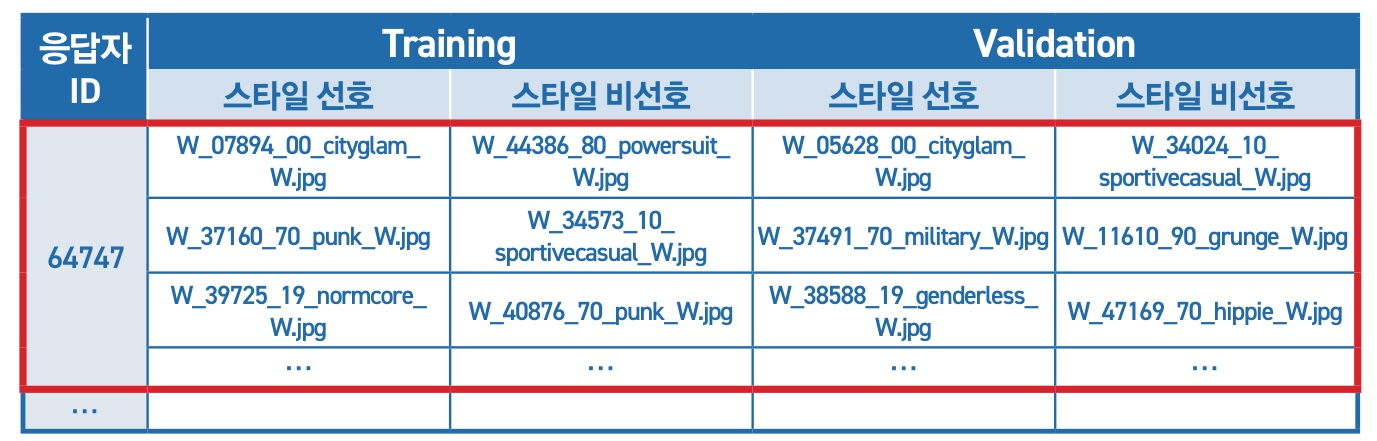

### **각 클래스 간의 비율과 선호/비선호 간의 비율을 고려한 층화샘플링 진행**

In [ ]:
import pickle

# 파일 경로 설정 (pickle 파일이 저장된 경로와 동일하게 설정)
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/class_indices_31.pkl'

# pickle 파일에서 데이터 로드
with open(pickle_file_path, 'rb') as f:
    data = pickle.load(f)

# 로드된 데이터에서 각 리스트를 변수로 할당
train_labels = data['train_labels']
#valid_labels = data['valid_labels']
train_class_indices = data['train_class_indices']
#valid_class_indices = data['valid_class_indices']

print("pickle 파일로부터 데이터가 로드되었습니다.")

pickle 파일로부터 데이터가 로드되었습니다.


In [ ]:
train_class_indices

[8,
 24,
 16,
 18,
 13,
 24,
 30,
 9,
 16,
 25,
 23,
 18,
 27,
 18,
 29,
 24,
 23,
 24,
 22,
 10,
 24,
 27,
 18,
 21,
 6,
 21,
 14,
 30,
 11,
 14,
 4,
 9,
 3,
 19,
 8,
 14,
 18,
 1,
 14,
 14,
 23,
 25,
 13,
 23,
 10,
 19,
 6,
 17,
 11,
 9,
 20,
 25,
 27,
 28,
 26,
 15,
 19,
 28,
 30,
 19,
 30,
 11,
 13,
 3,
 23,
 19,
 27,
 18,
 13,
 10,
 14,
 23,
 24,
 30,
 26,
 13,
 18,
 29,
 19,
 27,
 24,
 24,
 27,
 8,
 28,
 1,
 7,
 6,
 7,
 24,
 23,
 23,
 19,
 9,
 21,
 7,
 11,
 3,
 9,
 9,
 3,
 0,
 3,
 17,
 27,
 6,
 16,
 5,
 4,
 30,
 30,
 23,
 7,
 0,
 25,
 29,
 20,
 0,
 24,
 22,
 21,
 6,
 1,
 5,
 5,
 3,
 0,
 4,
 4,
 2,
 7,
 7,
 4,
 19,
 21,
 14,
 3,
 15,
 6,
 2,
 30,
 11,
 6,
 8,
 7,
 5,
 13,
 0,
 23,
 2,
 3,
 10,
 0,
 1,
 25,
 1,
 14,
 28,
 27,
 27,
 19,
 4,
 10,
 5,
 1,
 15,
 22,
 5,
 8,
 12,
 4,
 23,
 14,
 30,
 10,
 27,
 14,
 15,
 7,
 18,
 11,
 11,
 8,
 24,
 5,
 5,
 6,
 2,
 8,
 2,
 0,
 23,
 24,
 9,
 4,
 10,
 21,
 11,
 24,
 27,
 9,
 1,
 28,
 2,
 4,
 11,
 18,
 6,
 6,
 1,
 0,
 2,
 22,
 14,
 5,
 9,
 27

In [ ]:
def create_labels(image_files):
    labels = []
    for file in image_files:
        parts = file.split('_')
        style = parts[3]  # 스타일
        gender = parts[4][0]  # 성별
        class_label = f"{gender}_{style}"  # 성별과 스타일을 결합하여 클래스 라벨 생성
        labels.append(class_label)
    return labels

In [ ]:
# 고유한 클래스 레이블을 인덱스로 변환
unique_labels = sorted(set(train_labels))
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}

In [ ]:
unique_labels

['M_bold',
 'M_hiphop',
 'M_hippie',
 'M_ivy',
 'M_metrosexual',
 'M_mods',
 'M_normcore',
 'M_sportivecasual',
 'W_athleisure',
 'W_bodyconscious',
 'W_cityglam',
 'W_classic',
 'W_disco',
 'W_ecology',
 'W_feminine',
 'W_genderless',
 'W_grunge',
 'W_hiphop',
 'W_hippie',
 'W_kitsch',
 'W_lingerie',
 'W_lounge',
 'W_military',
 'W_minimal',
 'W_normcore',
 'W_oriental',
 'W_popart',
 'W_powersuit',
 'W_punk',
 'W_space',
 'W_sportivecasual']

In [ ]:
label_to_idx

{'M_bold': 0,
 'M_hiphop': 1,
 'M_hippie': 2,
 'M_ivy': 3,
 'M_metrosexual': 4,
 'M_mods': 5,
 'M_normcore': 6,
 'M_sportivecasual': 7,
 'W_athleisure': 8,
 'W_bodyconscious': 9,
 'W_cityglam': 10,
 'W_classic': 11,
 'W_disco': 12,
 'W_ecology': 13,
 'W_feminine': 14,
 'W_genderless': 15,
 'W_grunge': 16,
 'W_hiphop': 17,
 'W_hippie': 18,
 'W_kitsch': 19,
 'W_lingerie': 20,
 'W_lounge': 21,
 'W_military': 22,
 'W_minimal': 23,
 'W_normcore': 24,
 'W_oriental': 25,
 'W_popart': 26,
 'W_powersuit': 27,
 'W_punk': 28,
 'W_space': 29,
 'W_sportivecasual': 30}

여기서 train_restrutured_df의 변형이 일어남!!

In [ ]:
import pandas as pd

# create_labels 함수를 통해 파일 이름에서 라벨을 추출한 후, label_to_idx로 인덱스 변환
def apply_create_label_and_idx(row):
    # 이미지 파일 이름이 None이 아닌 경우에만 처리
    if row is not None:
        # 라벨 생성
        label = create_labels([row])[0]
        # 해당 라벨의 인덱스를 반환
        return label_to_idx.get(label, -1)  # 라벨이 없을 경우 -1 반환
    else:
        return -1  # None인 경우 -1로 처리

# train_restructured_df에서 '스타일 선호'와 '스타일 비선호'에 대해 라벨 적용 및 인덱스 추가
train_restructured_df['스타일 선호 라벨 인덱스'] = train_restructured_df['스타일 선호'].apply(apply_create_label_and_idx)
train_restructured_df['스타일 비선호 라벨 인덱스'] = train_restructured_df['스타일 비선호'].apply(apply_create_label_and_idx)

valid_restructured_df['스타일 선호 라벨 인덱스'] = valid_restructured_df['스타일 선호'].apply(apply_create_label_and_idx)
valid_restructured_df['스타일 비선호 라벨 인덱스'] = valid_restructured_df['스타일 비선호'].apply(apply_create_label_and_idx)

In [ ]:
train_restructured_df

,설문ID,스타일 선호,스타일 비선호,스타일 선호 라벨 인덱스,스타일 비선호 라벨 인덱스
0,41,W_03412_50_classic_W.jpg,None,11,-1
1,88,None,W_12740_00_metrosexual_M.jpg,-1,4
2,132,None,W_18990_50_feminine_W.jpg,-1,14
3,150,None,W_15212_60_mods_M.jpg,-1,5
4,151,W_03007_70_hippie_M.jpg,None,2,-1
...,...,...,...,...,...
16090,235703,None,W_24537_70_hippie_M.jpg,-1,2
16091,235729,None,W_25360_80_bold_M.jpg,-1,0
16092,246612,T_00456_10_sportivecasual_M.jpg,None,7,-1
16093,247040,None,T_01883_10_sportivecasual_M.jpg,-1,7


In [ ]:
valid_restructured_df

,설문ID,스타일 선호,스타일 비선호,스타일 선호 라벨 인덱스,스타일 비선호 라벨 인덱스
0,8,None,W_02651_50_feminine_W.jpg,-1,14
1,41,W_03412_50_classic_W.jpg,None,11,-1
2,157,W_17697_50_ivy_M.jpg,None,3,-1
3,174,W_06522_50_ivy_M.jpg,None,3,-1
4,198,W_07120_19_normcore_M.jpg,None,6,-1
...,...,...,...,...,...
4099,235581,None,W_17619_00_metrosexual_M.jpg,-1,4
4100,235626,None,W_04840_50_feminine_W.jpg,-1,14
4101,235634,W_04836_50_feminine_W.jpg,None,14,-1
4102,235695,None,W_24535_70_hippie_M.jpg,-1,2


### **각 클래스별 선호, 비선호 비율 및 클래스별 전체 비율 시각화**

valid_restructured_df에 대해서는 시각화를 진행할 필요가 없음. 비율을 고려해서 100명의 샘플을 추출하는 쪽은 training데이터으로부터 하기 때문.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# '스타일 선호 라벨 인덱스'와 '스타일 비선호 라벨 인덱스'의 이미지 수를 집계
class_labels = sorted(label_to_idx.values())  # 0~31까지의 라벨 인덱스

# 각 라벨 인덱스에 대해 선호/비선호 이미지 수 계산
preferred_counts = train_restructured_df['스타일 선호 라벨 인덱스'].value_counts().reindex(class_labels, fill_value=0)
non_preferred_counts = train_restructured_df['스타일 비선호 라벨 인덱스'].value_counts().reindex(class_labels, fill_value=0)

# x축에 실제 스타일과 성별을 나타내기 위한 레이블 생성
class_names = [label for label, idx in sorted(label_to_idx.items(), key=lambda x: x[1])]


In [ ]:
preferred_counts

,count
스타일 선호 라벨 인덱스,
0,359
1,463
2,317
3,861
4,306
5,851
6,575
7,913
8,187


In [ ]:
class_items = sorted(label_to_idx.items())
class_items

[('M_bold', 0),
 ('M_hiphop', 1),
 ('M_hippie', 2),
 ('M_ivy', 3),
 ('M_metrosexual', 4),
 ('M_mods', 5),
 ('M_normcore', 6),
 ('M_sportivecasual', 7),
 ('W_athleisure', 8),
 ('W_bodyconscious', 9),
 ('W_cityglam', 10),
 ('W_classic', 11),
 ('W_disco', 12),
 ('W_ecology', 13),
 ('W_feminine', 14),
 ('W_genderless', 15),
 ('W_grunge', 16),
 ('W_hiphop', 17),
 ('W_hippie', 18),
 ('W_kitsch', 19),
 ('W_lingerie', 20),
 ('W_lounge', 21),
 ('W_military', 22),
 ('W_minimal', 23),
 ('W_normcore', 24),
 ('W_oriental', 25),
 ('W_popart', 26),
 ('W_powersuit', 27),
 ('W_punk', 28),
 ('W_space', 29),
 ('W_sportivecasual', 30)]

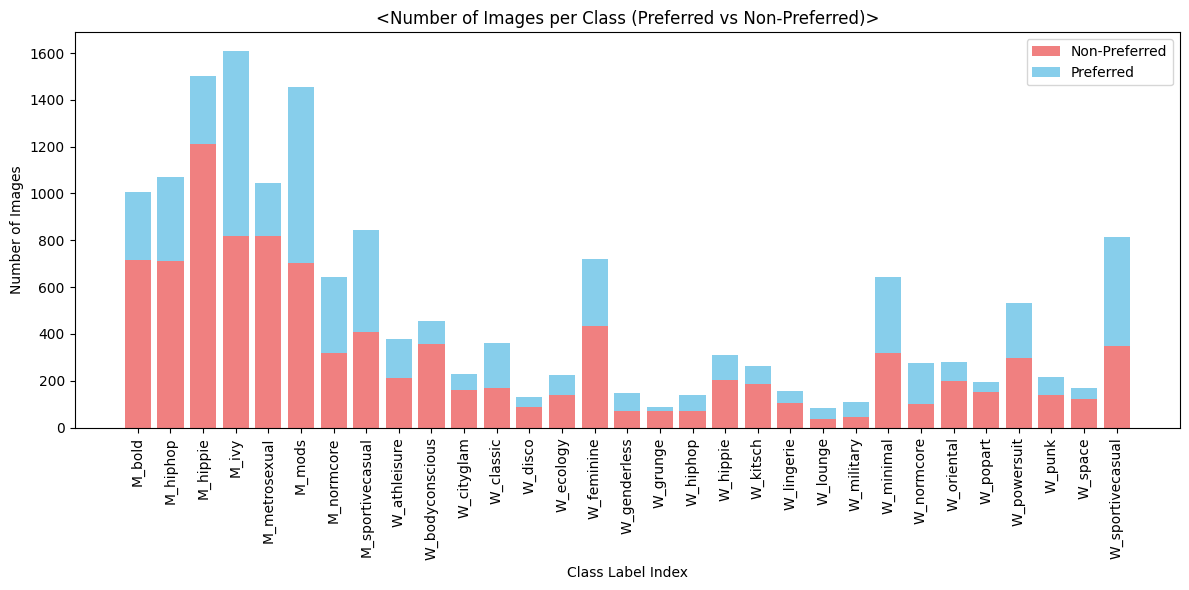

In [ ]:
# 누적 히스토그램 그리기
plt.figure(figsize=(12, 6))
plt.bar(class_labels, non_preferred_counts, color='lightcoral', label='Non-Preferred')
plt.bar(class_labels, preferred_counts, bottom=non_preferred_counts, color='skyblue', label='Preferred')

# x축과 y축 레이블, 제목, 범례 추가
plt.xticks(class_labels, class_names, rotation=90)
plt.xlabel('Class Label Index')
plt.ylabel('Number of Images')
plt.title('<Number of Images per Class (Preferred vs Non-Preferred)>')
plt.legend()

# 그래프 출력
plt.tight_layout()
plt.show()


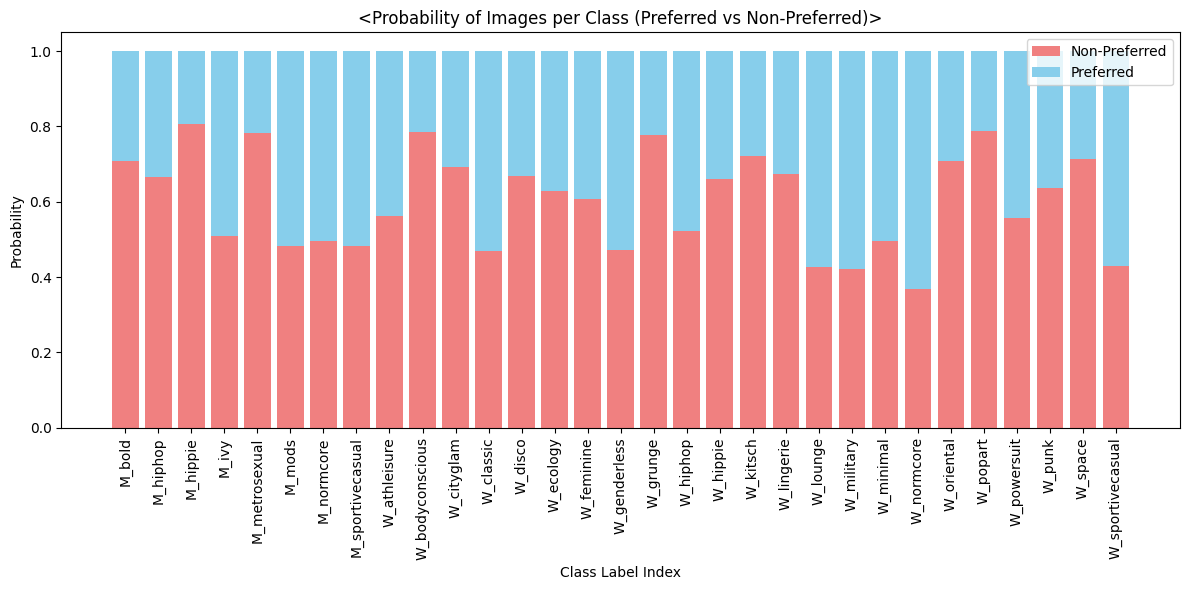

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# '스타일 선호 라벨 인덱스'와 '스타일 비선호 라벨 인덱스'의 이미지 수를 집계
class_labels = sorted(label_to_idx.values())  # 0~31까지의 라벨 인덱스

# 각 라벨 인덱스에 대해 선호/비선호 이미지 수 계산
preferred_counts = train_restructured_df['스타일 선호 라벨 인덱스'].value_counts().reindex(class_labels, fill_value=0)
non_preferred_counts = train_restructured_df['스타일 비선호 라벨 인덱스'].value_counts().reindex(class_labels, fill_value=0)

# 전체 이미지 수 계산 (선호와 비선호 이미지 수의 합)
total_counts = preferred_counts + non_preferred_counts

# 확률 계산 (이미지 수를 전체 이미지 수로 나누어 확률로 변환)
preferred_prob = preferred_counts / total_counts
non_preferred_prob = non_preferred_counts / total_counts

# NaN(0으로 나눔으로 인해 발생하는 경우)을 0으로 처리
preferred_prob.fillna(0, inplace=True)
non_preferred_prob.fillna(0, inplace=True)

# x축에 실제 스타일과 성별을 나타내기 위한 레이블 생성
class_names = [label for label, idx in sorted(label_to_idx.items(), key=lambda x: x[1])]

# 확률 히스토그램 그리기
plt.figure(figsize=(12, 6))
plt.bar(class_labels, non_preferred_prob, color='lightcoral', label='Non-Preferred')
plt.bar(class_labels, preferred_prob, bottom=non_preferred_prob, color='skyblue', label='Preferred')

# x축과 y축 레이블, 제목, 범례 추가
plt.xticks(class_labels, class_names, rotation=90)
plt.xlabel('Class Label Index')
plt.ylabel('Probability')
plt.title('<Probability of Images per Class (Preferred vs Non-Preferred)>')
plt.legend()

# 그래프 출력
plt.tight_layout()
plt.show()


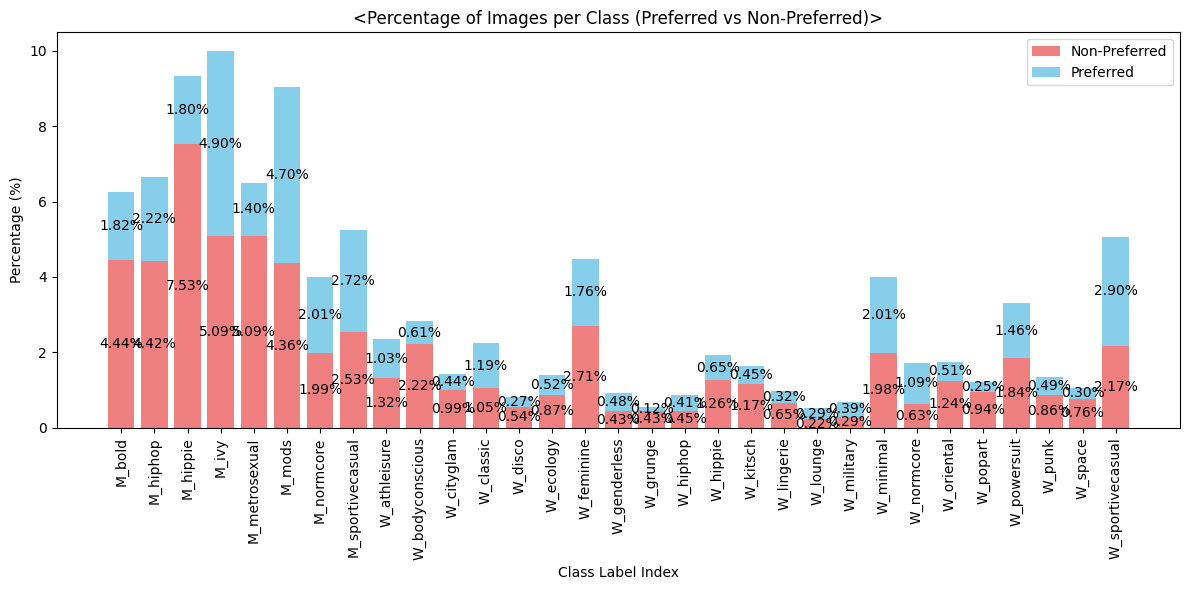

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# '스타일 선호 라벨 인덱스'와 '스타일 비선호 라벨 인덱스'의 이미지 수를 집계
class_labels = sorted(label_to_idx.values())  # 0~31까지의 라벨 인덱스

# 각 라벨 인덱스에 대해 선호/비선호 이미지 수 계산
preferred_counts = train_restructured_df['스타일 선호 라벨 인덱스'].value_counts().reindex(class_labels, fill_value=0)
non_preferred_counts = train_restructured_df['스타일 비선호 라벨 인덱스'].value_counts().reindex(class_labels, fill_value=0)

# 각 클래스에 속하는 이미지의 총 수 계산
total_class_counts = preferred_counts + non_preferred_counts
grand_total = total_class_counts.sum()

# 각 클래스의 이미지 수를 총 이미지 수로 나누어 백분율로 변환 (100%로 합쳐지도록)
preferred_percentage = (preferred_counts / grand_total) * 100
non_preferred_percentage = (non_preferred_counts / grand_total) * 100

# x축에 실제 스타일과 성별을 나타내기 위한 레이블 생성
class_names = [label for label, idx in sorted(label_to_idx.items(), key=lambda x: x[1])]

# 백분율 누적 히스토그램 그리기
plt.figure(figsize=(12, 6))
plt.bar(class_labels, non_preferred_percentage, color='lightcoral', label='Non-Preferred')
plt.bar(class_labels, preferred_percentage, bottom=non_preferred_percentage, color='skyblue', label='Preferred')

# 각 막대 위에 백분율 값 표시
for i, (preferred, non_preferred) in enumerate(zip(preferred_percentage, non_preferred_percentage)):
    plt.text(i, non_preferred_percentage[i] + preferred_percentage[i] / 2, f'{preferred_percentage[i]:.2f}%', ha='center', va='center', color='black')
    plt.text(i, non_preferred_percentage[i] / 2, f'{non_preferred_percentage[i]:.2f}%', ha='center', va='center', color='black')

# x축과 y축 레이블, 제목, 범례 추가
plt.xticks(class_labels, class_names, rotation=90)
plt.xlabel('Class Label Index')
plt.ylabel('Percentage (%)')
plt.title('<Percentage of Images per Class (Preferred vs Non-Preferred)>')
plt.legend()

# 그래프 출력
plt.tight_layout()
plt.show()


In [ ]:
# 가장 낮은 퍼센트 찾기
min_percentage = min(preferred_percentage.min(), non_preferred_percentage.min())

# 가장 낮은 퍼센트를 1로 변환할 스케일링 비율 계산
scaling_factor = 1 / min_percentage

# 모든 백분율 값을 스케일링
scaled_preferred_percentage = preferred_percentage * scaling_factor
scaled_non_preferred_percentage = non_preferred_percentage * scaling_factor

# 전체 스케일링된 백분율 합계 계산
total_scaled_percentage = scaled_preferred_percentage.sum() + scaled_non_preferred_percentage.sum()

# 결과 출력
print(f"가장 낮은 퍼센트를 1로 잡으면 전체 퍼센트 합은: {total_scaled_percentage:.2f}")


가장 낮은 퍼센트를 1로 잡으면 전체 퍼센트 합은: 804.75


최소 805개는 샘플링해야지 성별&스타일별&선호여부로 나눈 클래스의 비율을 맞게 뽑을 수 있음! 비율의 최소값을 가진 클래스가 적어도 샘플 1개를 가질 수 있게 됨!!

* 구현 아이디어:
1. 각 클래스별로 최소 2개의 샘플을 보장: 우선 각 클래스에서 선호와 비선호 각각 1개씩 할당하여, 각 클래스에 최소 2개의 샘플을 보장합니다.
2. 나머지 샘플은 층화 샘플링: 남은 샘플은 train_test_split의 stratify 매개변수를 사용하여 층화 샘플링으로 추출합니다.
3. 각 클래스에서 추출한 샘플이 100개가 되도록 조정: 최소 2개의 샘플을 할당한 후, 남은 샘플을 추출하여 총 100개의 샘플을 보장합니다.

In [ ]:
# valid_restructured_df의 설문ID와 겹치는 train_restructured_df의 설문ID 필터링
valid_ids = valid_restructured_df['설문ID'].unique()
filtered_train_df = train_restructured_df[~train_restructured_df['설문ID'].isin(valid_ids)]
#not_lapped_df = train_restructured_df[~train_restructured_df['설문ID'].isin(valid_ids)]

In [ ]:
train_ids = train_restructured_df['설문ID'].unique()
filtered_valid_df = valid_restructured_df[valid_restructured_df['설문ID'].isin(train_ids)]

In [ ]:
filtered_valid_df

,설문ID,스타일 선호,스타일 비선호,스타일 선호 라벨 인덱스,스타일 비선호 라벨 인덱스
1,41,W_03412_50_classic_W.jpg,None,11,-1
5,232,W_18249_50_feminine_W.jpg,None,14,-1
7,484,None,W_10073_70_hippie_M.jpg,-1,2
9,636,None,W_14147_70_disco_W.jpg,-1,12
10,670,W_12803_70_hippie_M.jpg,None,2,-1
...,...,...,...,...,...
4098,235578,None,W_24543_70_hippie_M.jpg,-1,2
4099,235581,None,W_17619_00_metrosexual_M.jpg,-1,4
4100,235626,None,W_04840_50_feminine_W.jpg,-1,14
4101,235634,W_04836_50_feminine_W.jpg,None,14,-1


In [ ]:
len(valid_ids)

4262

In [ ]:
not_lapped_df # 17831 rows × 5 columns

,설문ID,스타일 선호,스타일 비선호,스타일 선호 라벨 인덱스,스타일 비선호 라벨 인덱스
1,88,None,W_12740_00_metrosexual_M.jpg,-1,4
2,132,None,W_18990_50_feminine_W.jpg,-1,14
3,150,None,W_15212_60_mods_M.jpg,-1,5
4,151,W_03007_70_hippie_M.jpg,None,2,-1
5,152,W_16068_80_bold_M.jpg,None,0,-1
...,...,...,...,...,...
16089,235681,None,W_17455_00_metrosexual_M.jpg,-1,4
16090,235703,None,W_24537_70_hippie_M.jpg,-1,2
16091,235729,None,W_25360_80_bold_M.jpg,-1,0
16093,247040,None,T_01883_10_sportivecasual_M.jpg,-1,7


In [ ]:
filtered_train_df # 2472 rows × 5 columns

# 20303-> 2472개로 줄어들음

,설문ID,스타일 선호,스타일 비선호,스타일 선호 라벨 인덱스,스타일 비선호 라벨 인덱스
1,88,None,W_12740_00_metrosexual_M.jpg,-1,4
2,132,None,W_18990_50_feminine_W.jpg,-1,14
3,150,None,W_15212_60_mods_M.jpg,-1,5
4,151,W_03007_70_hippie_M.jpg,None,2,-1
5,152,W_16068_80_bold_M.jpg,None,0,-1
...,...,...,...,...,...
16089,235681,None,W_17455_00_metrosexual_M.jpg,-1,4
16090,235703,None,W_24537_70_hippie_M.jpg,-1,2
16091,235729,None,W_25360_80_bold_M.jpg,-1,0
16093,247040,None,T_01883_10_sportivecasual_M.jpg,-1,7


In [ ]:
valid_restructured_df[valid_restructured_df['설문ID'] == 670]

,설문ID,스타일 선호,스타일 비선호,스타일 선호 라벨 인덱스,스타일 비선호 라벨 인덱스
10,670,W_12803_70_hippie_M.jpg,None,2,-1


In [ ]:
filtered_train_df.groupby('설문ID').size().describe()

,0
count,2472.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [ ]:
import pandas as pd

# filtered_train_df와 valid_restructured_df 두 개의 데이터프레임이 있다고 가정합니다.
# 두 데이터프레임의 예시를 생략하고, 실제 데이터프레임을 사용한다고 가정합니다.

# '설문ID'가 같을 때 '스타일 선호 라벨 인덱스'와 '스타일 비선호 라벨 인덱스' 비교
merged_df = pd.merge(filtered_train_df[['설문ID', '스타일 선호', '스타일 비선호']],
                     valid_restructured_df[['설문ID', '스타일 선호', '스타일 비선호']],
                     on='설문ID', suffixes=('_train', '_valid'))

# NaN 값을 0으로 채우기
merged_df.fillna(0, inplace=True)

# 각 라벨 인덱스를 비교하여 boolean 값 반환
comparison_df = pd.DataFrame({
    '스타일 선호 비교': merged_df['스타일 선호_train'] == merged_df['스타일 선호_valid'],
    '스타일 비선호 비교': merged_df['스타일 비선호_train'] == merged_df['스타일 비선호_valid']
})

# 결과 출력
print(comparison_df)

      스타일 선호 비교  스타일 비선호 비교
0          True        True
1          True        True
2          True        True
3          True        True
4          True        True
...         ...         ...
2439       True        True
2440       True        True
2441       True        True
2442       True        True
2443       True        True

[2444 rows x 2 columns]


In [ ]:
import pandas as pd

# 예시로 만들어진 comparison_df 가 있다고 가정합니다.

# 각 행에 대해 '스타일 선호 비교'와 '스타일 비선호 비교'가 둘 중 하나라도 False일 때, 그 행의 번호(index)를 출력
false_rows = comparison_df[(comparison_df['스타일 선호 비교'] == False) | (comparison_df['스타일 비선호 비교'] == False)].index

# 행 번호 출력
print("False가 있는 행 번호:", list(false_rows))


False가 있는 행 번호: []


In [ ]:
import pandas as pd

# filtered_train_df와 valid_restructured_df 두 개의 데이터프레임이 있다고 가정합니다.
# 두 데이터프레임의 예시를 생략하고, 실제 데이터프레임을 사용한다고 가정합니다.

# '설문ID'가 같을 때 '스타일 선호 라벨 인덱스'와 '스타일 비선호 라벨 인덱스' 비교
merged_df = pd.merge(filtered_train_df[['설문ID', '스타일 선호 라벨 인덱스', '스타일 비선호 라벨 인덱스']],
                     valid_restructured_df[['설문ID', '스타일 선호 라벨 인덱스', '스타일 비선호 라벨 인덱스']],
                     on='설문ID', suffixes=('_train', '_valid'))

# 각 라벨 인덱스를 비교하여 boolean 값 반환
comparison_df = pd.DataFrame({
    '스타일 선호 비교': merged_df['스타일 선호 라벨 인덱스_train'] == merged_df['스타일 선호 라벨 인덱스_valid'],
    '스타일 비선호 비교': merged_df['스타일 비선호 라벨 인덱스_train'] == merged_df['스타일 비선호 라벨 인덱스_valid']
})

# 결과 출력
print(comparison_df)


      스타일 선호 비교  스타일 비선호 비교
0          True        True
1          True        True
2          True        True
3          True        True
4          True        True
...         ...         ...
2467       True        True
2468       True        True
2469       True        True
2470       True        True
2471       True        True

[2472 rows x 2 columns]


In [ ]:
merged_df

,설문ID,스타일 선호 라벨 인덱스_train,스타일 비선호 라벨 인덱스_train,스타일 선호 라벨 인덱스_valid,스타일 비선호 라벨 인덱스_valid
0,41,11,-1,11,-1
1,232,14,-1,14,-1
2,484,-1,2,-1,2
3,636,-1,12,-1,12
4,670,2,-1,2,-1
...,...,...,...,...,...
2467,235626,-1,14,-1,14
2468,235634,14,-1,14,-1
2469,246612,7,-1,7,-1
2470,248802,-1,7,-1,7


In [ ]:
import pandas as pd

# 1. 최소 샘플 수 보장: 각 클래스에서 선호 1개, 비선호 1개씩 최소 2개 샘플 할당
def ensure_min_samples(df, label_col):
    # 각 클래스에서 선호와 비선호 각각 1개씩 추출
    selected_rows = []
    for class_idx in df[label_col].unique():
        # 선호 라벨에 대한 샘플
        preferred_rows = df[df['스타일 선호 라벨 인덱스'] == class_idx]
        if not preferred_rows.empty:
            selected_rows.append(preferred_rows.sample(1))

        # 비선호 라벨에 대한 샘플
        non_preferred_rows = df[df['스타일 비선호 라벨 인덱스'] == class_idx]
        if not non_preferred_rows.empty:
            selected_rows.append(non_preferred_rows.sample(1))

    # 최소 샘플 보장 리스트를 DataFrame으로 병합
    min_sample_df = pd.concat(selected_rows, ignore_index=False)
    return min_sample_df

# 최소 2개 샘플 보장
min_sample_df = ensure_min_samples(filtered_train_df, '스타일 선호 라벨 인덱스')


In [ ]:
min_sample_df

,설문ID,스타일 선호,스타일 비선호,스타일 선호 라벨 인덱스,스타일 비선호 라벨 인덱스
721,10639,None,W_03787_80_bodyconscious_W.jpg,-1,9
4016,66422,W_08345_00_ecology_W.jpg,None,13,-1
11496,139680,W_11052_70_hippie_M.jpg,None,2,-1
16090,235703,None,W_24537_70_hippie_M.jpg,-1,2
3002,45533,W_30483_80_bold_M.jpg,None,0,-1
...,...,...,...,...,...
9856,128535,None,W_11167_00_cityglam_W.jpg,-1,10
6180,96867,W_05775_80_bodyconscious_W.jpg,None,9,-1
2643,39630,None,W_08578_80_bodyconscious_W.jpg,-1,9
11326,138280,W_04097_90_grunge_W.jpg,None,16,-1


In [ ]:
# 2. 층화 샘플링: 남은 샘플 중에서 나머지 100 - len(min_sample_df) 개를 층화 샘플링
remaining_df = filtered_train_df.drop(min_sample_df.index)


In [ ]:
from sklearn.model_selection import train_test_split

# 3. '스타일 선호 라벨 인덱스'와 '스타일 비선호 라벨 인덱스'를 결합하여 유효한 라벨을 생성
def create_combined_label(row):
    if row['스타일 선호 라벨 인덱스'] != -1:
        return row['스타일 선호 라벨 인덱스']  # 스타일 선호가 유효하면 이를 사용
    elif row['스타일 비선호 라벨 인덱스'] != -1:
        return row['스타일 비선호 라벨 인덱스']  # 비선호가 유효하면 이를 사용
    else:
        return -1  # 둘 다 유효하지 않으면 -1

# 각 행에 대해 combined_label 생성
remaining_df['combined_label'] = remaining_df.apply(create_combined_label, axis=1)

# 4. 층화 샘플링: 새로운 결합된 라벨을 기준으로 층화 샘플링
n_remaining_samples = 36
_, stratified_sample_df = train_test_split(
    remaining_df,
    test_size=n_remaining_samples,
    stratify=remaining_df['combined_label'],
    random_state=42
)

# 5. 최종 샘플: 최소 샘플과 층화 샘플을 병합
final_sample_df = pd.concat([min_sample_df, stratified_sample_df], ignore_index=True)

# 결과 확인
final_sample_df[63:]


,설문ID,스타일 선호,스타일 비선호,스타일 선호 라벨 인덱스,스타일 비선호 라벨 인덱스,combined_label
63,16479,None,W_06437_90_grunge_W.jpg,-1,16,NaN
64,209462,W_18297_50_classic_W.jpg,None,11,-1,11.0
65,164125,W_33622_60_minimal_W.jpg,None,23,-1,23.0
66,152879,W_43737_80_powersuit_W.jpg,None,27,-1,27.0
67,108456,None,W_15474_80_bold_M.jpg,-1,0,0.0
68,177837,W_56037_00_oriental_W.jpg,None,25,-1,25.0
69,146020,None,W_10793_50_ivy_M.jpg,-1,3,3.0
70,120646,W_12784_10_sportivecasual_M.jpg,None,7,-1,7.0
71,63337,None,W_19859_70_punk_W.jpg,-1,28,28.0
72,29841,None,W_14704_60_minimal_W.jpg,-1,23,23.0


* 선호/비선호 비율 및 각 클래스별 비율을 고려하고 샘플을 100개를 추출하기에는 클래스 개수 대비 샘플의 전체 수가 부족한 점이 아쉬웠다. 샘플링 개수 제한이 없었다면 더 좋은 샘플링을 진행할 수 있었을 것으로 보인다.
* 성별&스타일별 클래스 * (선호 or 비선호)이므로 62개의 클래스가 생성된다-> 따라서 먼저 62개의 샘플을 뽑고, 나머지 36개의 샘플을 뽑을 때 층화 샘플링을 진행하였다.

* final_sample_df의 combined_label컬럼의 출력값은 0~63번째 인덱스까지 NaN인 걸 확인할 수 있는데, 이는 층화 샘플링과 관련없는 처음에 먼저 뽑은 샘플들을 의미한다.

* 성별&스타일로 나눠진 31개의 클래스의 각각 선호, 비선호 샘플을 골라서 뽑음으로써, 샘플의 다양성을 보장하였다.

* <font color="red">또한 과대적합을 방지하기 위해, validation데이터에 겹치지 않은 '설문ID'에 한정 샘플링을 진행하였다. 아니면 문제에서 제시한 "스타일 선호 정보표"의 모양을 맞추기 위해 training와 validation데이터에서 겹치는 '설문ID'로 제한시켜 샘플링을 진행해야 하는지 궁금하다. 제한시키지 않는다면 validation데이터의 100명의 응답자ID에 대한 스타일 선호, 비선호는 랜덤 샘플링으로 간단하게 추출하면 된다.</font>

### **Mission 2-2. "스타일 선호 정보표"**

In [ ]:
final_sample_df_subset = final_sample_df.iloc[:, :3]
final_sample_df_subset

,설문ID,스타일 선호,스타일 비선호
0,126836,None,W_08004_60_popart_W.jpg
1,86656,W_14770_60_minimal_W.jpg,None
2,109249,W_00951_70_hippie_M.jpg,None
3,196567,None,W_02715_70_hippie_M.jpg
4,150721,W_27048_80_bold_M.jpg,None
...,...,...,...
95,42298,None,W_24080_00_metrosexual_M.jpg
96,33733,W_00486_60_mods_M.jpg,None
97,105023,None,W_06537_50_ivy_M.jpg
98,126647,None,W_00507_90_hiphop_M.jpg


In [ ]:
print(train_restructured_df)
print(valid_restructured_df)
print(final_sample_df)

         설문ID                           스타일 선호  \
0          41         W_03412_50_classic_W.jpg   
1          88                             None   
2         132                             None   
3         150                             None   
4         151          W_03007_70_hippie_M.jpg   
...       ...                              ...   
16090  235703                             None   
16091  235729                             None   
16092  246612  T_00456_10_sportivecasual_M.jpg   
16093  247040                             None   
16094  247133  T_02527_10_sportivecasual_M.jpg   

                               스타일 비선호  스타일 선호 라벨 인덱스  스타일 비선호 라벨 인덱스  
0                                 None             11              -1  
1         W_12740_00_metrosexual_M.jpg             -1               4  
2            W_18990_50_feminine_W.jpg             -1              14  
3                W_15212_60_mods_M.jpg             -1               5  
4                                 None 

In [ ]:
import pickle

# 파일 경로 설정
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/241024_final_samples_dataframes.pkl'

# 4개의 리스트를 pickle로 저장
with open(pickle_file_path, 'wb') as f:
    pickle.dump({
        'train_restructured_df': train_restructured_df,
        'valid_restructured_df': valid_restructured_df,
        'final_sample_df': final_sample_df
    }, f)

print("리스트가 pickle 파일로 저장되었습니다.")

리스트가 pickle 파일로 저장되었습니다.


# Mission 3. 패션 스타일 선호 여부 예측

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# ResNet-18 모델 불러오기
model = models.resnet18(pretrained=True)
model = nn.Sequential(*list(model.children())[:-1])  # 마지막 레이어를 제외하여 중간 feature 추출

# 모델을 평가 모드로 설정
model.eval()

# 이미지 전처리 변환 정의 (ResNet-18에 맞는 입력 크기로 조정)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 92.8MB/s]


In [ ]:
import os

def extract_feature_vector(image_path, model):
    """이미지 파일에서 feature vector를 추출하는 함수"""
    image = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(image).unsqueeze(0)  # 배치 차원 추가
    with torch.no_grad():
        feature_vector = model(input_tensor).squeeze().numpy()  # feature vector 추출
    return feature_vector

# final_sample_df에 있는 각 이미지에 대해 feature vector 추출
feature_vectors = []
error_files = []  # 에러가 발생한 파일을 저장할 리스트

for idx, row in final_sample_df.iterrows():
    image_path = os.path.join(training_image_dir, row['스타일 선호'] or row['스타일 비선호'])  # 이미지 경로 설정

    if image_path is not None:
        feature_vector = extract_feature_vector(image_path, model)
        feature_vectors.append(feature_vector)


In [ ]:
import pickle

# 파일 경로 설정
pickle_file_path = '/content/drive/MyDrive/data_creator_camp/feature_vector.pkl'

# 4개의 리스트를 pickle로 저장
with open(pickle_file_path, 'wb') as f:
    pickle.dump({
        'feature_vectors': feature_vectors
    }, f)

print("리스트가 pickle 파일로 저장되었습니다.")

리스트가 pickle 파일로 저장되었습니다.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# feature vector 배열로 변환 (밀집 행렬)
feature_matrix = np.array(feature_vectors) # 100rows * 512cols

# 코사인 유사도 계산
cosine_sim_matrix = cosine_similarity(feature_matrix)

# 결과 확인
print(cosine_sim_matrix) # 100rows * 100cols

[[1.0000002  0.6881885  0.6680466  ... 0.70955175 0.6842645  0.663537  ]
 [0.6881885  0.99999976 0.70488787 ... 0.71113515 0.7159595  0.67324567]
 [0.6680466  0.70488787 1.0000002  ... 0.75655204 0.72648865 0.6402279 ]
 ...
 [0.70955175 0.71113515 0.75655204 ... 0.9999999  0.68063664 0.65063405]
 [0.6842645  0.7159595  0.72648865 ... 0.68063664 0.9999999  0.7170502 ]
 [0.663537   0.67324567 0.6402279  ... 0.65063405 0.7170502  1.0000004 ]]


In [ ]:
import numpy as np
import pandas as pd

# final_sample_df와 cosine_sim_matrix가 있다고 가정

# 각 행마다 코사인 유사도가 가장 높은 3개의 이미지 선택
top_k = 3  # 상위 3개의 유사도 선택
top_k_indices = []

for i in range(cosine_sim_matrix.shape[0]):
    # 자기 자신을 제외하고 코사인 유사도가 가장 높은 3개 인덱스 추출
    sorted_indices = np.argsort(-cosine_sim_matrix[i])  # 유사도가 높은 순서로 정렬
    top_k_indices.append(sorted_indices[1:top_k + 1])  # 자기 자신 제외하고 상위 3개 선택

# 각 행에 대한 성별, 스타일, 선호도 정보 출력
top_k_info = []
for i, indices in enumerate(top_k_indices):
    row_info = []
    for idx in indices:
        row = final_sample_df.iloc[idx]
        gender_style_preference = {
            '설문ID': row['설문ID'],
            '스타일 선호': row['스타일 선호'],
            '스타일 비선호': row['스타일 비선호'],
            '성별 & 스타일 & 선호도 여부': f"{row['스타일 선호'] or row['스타일 비선호']}"
        }
        row_info.append(gender_style_preference)
    top_k_info.append(row_info)

# 상위 3개의 정보 출력
for i, info in enumerate(top_k_info):
    print(f"\n--- Row {i}의 상위 3개 유사도 아이템 ---")
    for j, item in enumerate(info):
        print(f"Top {j+1}: {item['성별 & 스타일 & 선호도 여부']} (설문ID: {item['설문ID']})")



--- Row 0의 상위 3개 유사도 아이템 ---
Top 1: W_04630_00_metrosexual_M.jpg (설문ID: 104670)
Top 2: W_07554_70_hippie_W.jpg (설문ID: 117250)
Top 3: W_02086_19_normcore_W.jpg (설문ID: 134790)

--- Row 1의 상위 3개 유사도 아이템 ---
Top 1: W_00153_60_minimal_W.jpg (설문ID: 202868)
Top 2: W_28908_90_hiphop_M.jpg (설문ID: 147882)
Top 3: W_00410_19_genderless_W.jpg (설문ID: 108110)

--- Row 2의 상위 3개 유사도 아이템 ---
Top 1: W_10880_60_minimal_W.jpg (설문ID: 5947)
Top 2: W_14217_70_punk_W.jpg (설문ID: 119640)
Top 3: W_08809_19_lounge_W.jpg (설문ID: 123310)

--- Row 3의 상위 3개 유사도 아이템 ---
Top 1: W_17220_19_normcore_M.jpg (설문ID: 91629)
Top 2: W_00856_10_sportivecasual_M.jpg (설문ID: 164121)
Top 3: W_29178_90_hiphop_M.jpg (설문ID: 126017)

--- Row 4의 상위 3개 유사도 아이템 ---
Top 1: W_60188_10_sportivecasual_M.jpg (설문ID: 217777)
Top 2: W_11824_70_military_W.jpg (설문ID: 134752)
Top 3: W_00410_19_genderless_W.jpg (설문ID: 108110)

--- Row 5의 상위 3개 유사도 아이템 ---
Top 1: W_18297_50_classic_W.jpg (설문ID: 209462)
Top 2: W_17220_19_normcore_M.jpg (설문ID: 91629)
Top 

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# 이미지 파일 경로가 포함된 열 '스타일 선호' 또는 '스타일 비선호'를 이용해 이미지를 불러오는 함수
def load_image(image_path):
    try:
        img = Image.open(image_path)
        return img
    except FileNotFoundError:
        print(f"이미지 {image_path}을(를) 찾을 수 없습니다.")
        return None

# 성별, 스타일, 선호/비선호 여부 추출 함수
def get_gender_style_preference(row):
    # row에서 '스타일 선호' 또는 '스타일 비선호' 중 어느 쪽이 None이 아닌지 확인
    if pd.notna(row['스타일 선호']):  # '스타일 선호'에 값이 있으면 P
        file_name = row['스타일 선호']
        preference = 'P'  # 선호
    else:
        file_name = row['스타일 비선호']
        preference = 'N'  # 비선호

    # 파일 이름에서 성별과 스타일 추출
    parts = file_name.split('_')
    gender = parts[-1][0]  # 파일 이름의 마지막 부분에서 성별(M 또는 W)
    style = parts[3]       # 스타일 이름

    return gender, style, preference

# 각 행마다 가장 유사한 3개의 이미지 시각화 (행의 이미지도 포함하여 총 4개)
for i, indices in enumerate(top_k_indices):
    plt.figure(figsize=(20, 5))  # 큰 화면을 위해 figsize 조정
    plt.suptitle(f"##{i}##", fontsize=16)

    # 현재 행의 이미지 시각화
    current_row = final_sample_df.iloc[i]
    file_name = current_row['스타일 선호'] or current_row['스타일 비선호']
    image_path = os.path.join(training_image_dir, file_name)
    img = load_image(image_path)

    if img is not None:
        plt.subplot(1, 4, 1)
        plt.imshow(img)
        gender, style, preference = get_gender_style_preference(current_row)
        plt.title(f"{gender}, {style}, {preference}", fontsize=12)
        plt.axis('off')

    # 상위 3개의 유사한 이미지 시각화
    for j, idx in enumerate(indices):
        row = final_sample_df.iloc[idx]  # 유사한 이미지를 가진 행
        file_name = row['스타일 선호'] or row['스타일 비선호']
        image_path = os.path.join(training_image_dir, file_name)
        img = load_image(image_path)

        if img is not None:
            plt.subplot(1, 4, j+2)  # 두 번째부터 네 번째까지의 subplot
            gender, style, preference = get_gender_style_preference(row)
            plt.imshow(img)
            plt.title(f"Top {j+1}: {gender}, {style}, {preference}", fontsize=12)
            plt.axis('off')

    plt.show()


Output hidden; open in https://colab.research.google.com to view.